# 📘 Chapter 10 — Building Neural Networks with PyTorch
## Türkçe Kod Açıklamaları

> **Kaynak:** *Hands-On Machine Learning with Scikit-Learn and PyTorch* — Aurélien Géron  
> Terimler **İngilizce** ön planda tutulmuş, Türkçe karşılıkları **(parantez içinde)** belirtilmiştir.

---

## İçindekiler
1. [PyTorch Fundamentals — Tensors](#1)
2. [Hardware Acceleration](#2)
3. [Autograd](#3)
4. [Linear Regression — Low Level API](#4)
5. [Linear Regression — High Level API](#5)
6. [Regression MLP](#6)
7. [Mini-Batch Gradient Descent & DataLoader](#7)
8. [Custom Module — Wide & Deep](#8)
9. [Multiple Inputs / Outputs](#9)
10. [Image Classifier with TorchVision](#10)
11. [Hyperparameter Tuning with Optuna](#11)
12. [Saving & Loading Models](#12)
13. [TorchScript & torch.compile](#13)
14. [Exercises — Alıştırmalar](#14)


---
<a id='s1'></a>
## Setup & Environment Checks (Ortam Kontrolleri)

Notebook, çalışmadan önce gerekli minimum versiyonları doğrular.  
Bu tür assertion (doğrulama) blokları, uyumsuz ortamda çalıştırıldığında açık hata verir.


### Python ve Scikit-Learn Versiyon Kontrolü

In [1]:
import sys
assert sys.version_info >= (3, 10), "Python 3.10+ gerekli"

from packaging.version import Version
import sklearn
assert Version(sklearn.__version__) >= Version("1.6.1"), "Scikit-Learn 1.6.1+ gerekli"

print(f"Python {sys.version_info.major}.{sys.version_info.minor} — OK")
print(f"Scikit-Learn {sklearn.__version__} — OK")

AssertionError: Python 3.10+ gerekli

### Matplotlib Varsayılan Font Boyutları

In [2]:
import matplotlib.pyplot as plt

# Grafiklerin daha okunabilir görünmesi için global font ayarları
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print("Matplotlib ayarları yapıldı.")

Matplotlib ayarları yapıldı.


---
<a id='1'></a>
## 1. PyTorch Fundamentals — Tensors (Temel Kavramlar)

PyTorch'un temel veri yapısı **tensor** (çok boyutlu dizi)'dir.  
NumPy array'ine benzer, ancak iki kritik ek özelliği vardır:
- **GPU/hardware acceleration** (donanım hızlandırma) desteği
- **Autograd** (otomatik türev) desteği


### `import torch` — Kütüphaneyi İçe Aktarma

In [3]:
conda install pytorch torchvision torchaudio -c pytorch

Solving environment: / 
The environment is inconsistent, please check the package plan carefully
The following packages are causing the inconsistency:

  - defaults/osx-64::holoviews==1.15.0=py39hecd8cb5_0
  - defaults/osx-64::scikit-learn==1.0.2=py39hae1ba45_1
  - defaults/noarch::arrow==1.2.2=pyhd3eb1b0_0
  - defaults/osx-64::astroid==2.11.7=py39hecd8cb5_0
  - defaults/noarch::nbclassic==0.3.5=pyhd3eb1b0_0
  - defaults/noarch::cookiecutter==1.7.3=pyhd3eb1b0_0
  - defaults/noarch::argon2-cffi==21.3.0=pyhd3eb1b0_0
  - defaults/noarch::pyls-spyder==0.4.0=pyhd3eb1b0_0
  - defaults/osx-64::scikit-learn-intelex==2021.6.0=py39hecd8cb5_0
  - defaults/osx-64::jupyterlab==3.4.4=py39hecd8cb5_0
  - defaults/osx-64::datashader==0.14.1=py39hecd8cb5_0
  - defaults/osx-64::anaconda==2022.10=py39_0
  - defaults/osx-64::scrapy==2.6.2=py39hecd8cb5_0
  - defaults/osx-64::hvplot==0.8.0=py39hecd8cb5_0
  - defaults/noarch::nltk==3.7=pyhd3eb1b0_0
  - defaults/osx-64::python-lsp-black==1.2.1=py39hecd8cb5_0
 

In [3]:
import torch
print('PyTorch version:', torch.__version__)

PyTorch version: 2.2.2


### Tensor (Çok Boyutlu Dizi) Oluşturma

`torch.tensor()` — Python listesinden tensor oluşturur.  
İki liste → 2 satır → **2×3 matrix** (matris).  
Değerler `float` olduğundan `dtype` (veri tipi) otomatik `float32` seçilir.


In [4]:
X = torch.tensor([[1.0, 4.0, 7.0], [2.0, 3.0, 6.0]])
print(X)

tensor([[1., 4., 7.],
        [2., 3., 6.]])


### `.shape` ve `.dtype` — Şekil ve Veri Tipi Sorgulama

- `.shape` → tensörün boyutunu döner. `[2, 3]` = 2 satır, 3 sütun.  
- `.dtype` → veri tipini gösterir.  
  - PyTorch varsayılan: **`float32`** (32-bit).  
  - NumPy varsayılan: `float64` (64-bit).  
  - Deep learning (derin öğrenme) için `float32` yeterince hassas ve **2× daha hızlı**.


### Indexing & Slicing (İndeksleme ve Dilimleme)

NumPy ile **birebir aynı syntax** (sözdizimi):  
- `X[satır, sütun]` → tek eleman  
- `X[:, sütun]` → tüm satırların belirli sütunu (`:` = tümünü seç)


In [5]:
print('X[0, 1] =', X[0, 1])   # 0. satır, 1. sütun → tensor(4.)
print('X[:, 1] =', X[:, 1])   # tüm satırların 1. sütunu

X[0, 1] = tensor(4.)
X[:, 1] = tensor([4., 3.])


### Temel Matematiksel İşlemler

| İşlem | Açıklama |
|-------|----------|
| `10 * (X + 1.0)` | Itemwise (eleman bazlı) toplama ve çarpma |
| `X.exp()` | Eleman bazlı üstel fonksiyon (eˣ) |
| `X.mean()` | Tüm elemanların aritmetik ortalaması |
| `X.max(dim=0)` | Her **sütun**'un maksimumu (`dim=0`: satır yönünde) |
| `X @ X.T` | Matrix multiplication (matris çarpımı) + transpose (devrik) |

> **`dim=0`** → satırlar boyunca işlem (her sütun için sonuç)  
> **`dim=1`** → sütunlar boyunca işlem (her satır için sonuç)  
> **`@`** operatörü → `torch.matmul()` ile eşdeğer


In [6]:
print('10 * (X + 1.0):', 10 * (X + 1.0))  # itemwise
print('X.exp():\n', X.exp())               # eleman bazlı e^x
print('X.mean():', X.mean())               # genel ortalama
print('X.max(dim=0):', X.max(dim=0))       # sütun maksimumları
print('X @ X.T:\n', X @ X.T)              # matris çarpımı

10 * (X + 1.0): tensor([[20., 50., 80.],
        [30., 40., 70.]])
X.exp():
 tensor([[   2.7183,   54.5981, 1096.6332],
        [   7.3891,   20.0855,  403.4288]])
X.mean(): tensor(3.8333)
X.max(dim=0): torch.return_types.max(
values=tensor([2., 4., 7.]),
indices=tensor([1, 0, 0]))
X @ X.T:
 tensor([[66., 56.],
        [56., 49.]])


### NumPy Dönüşümleri

| Yöntem | Açıklama |
|--------|----------|
| `X.numpy()` | Tensor → NumPy array (**kopyasız**, CPU'da gerekir) |
| `torch.tensor(np_arr)` | NumPy → Tensor (**kopya** oluşturur) |
| `torch.FloatTensor(np_arr)` | NumPy → float32 Tensor (otomatik dönüşüm) |
| `torch.from_numpy(np_arr)` | NumPy → Tensor (**veriyi paylaşır, kopya yok!**) |

> ⚠️ **`from_numpy()` uyarısı:** NumPy array değişirse tensor da değişir (ve tersi).


In [7]:
import numpy as np

print('Tensor → NumPy:\n', X.numpy())

arr = np.array([[1., 4., 7.], [2., 3., 6.]])
print('NumPy → Tensor (kopya):\n', torch.tensor(arr, dtype=torch.float32))
print('NumPy → FloatTensor:\n', torch.FloatTensor(arr))

Tensor → NumPy:
 [[1. 4. 7.]
 [2. 3. 6.]]
NumPy → Tensor (kopya):
 tensor([[1., 4., 7.],
        [2., 3., 6.]])
NumPy → FloatTensor:
 tensor([[1., 4., 7.],
        [2., 3., 6.]])


> ⚠️ **Neden önemli?**  
> Veri ön işleme sırasında NumPy array'i değiştirirseniz,  
> `from_numpy()` ile oluşturulan tensörler de sessizce değişir → beklenmedik bug kaynağı.  
>  
> Güvenli alternatif: `torch.tensor(arr)` → her zaman kopya oluşturur.


---
<a id='s3'></a>
##  NumPy–PyTorch Ortak Fonksiyonları Listeleme

`dir(mod)` → modülün tüm attribute (öznitelik) ve method (metod) isimlerini listeler.  
`callable()` → bir nesnenin çağrılabilir (fonksiyon/metod) olup olmadığını kontrol eder.  
`set & set` → iki kümenin kesişimi (intersection) — her iki modülde de bulunanlar.

Bu kod, PyTorch'un NumPy API'siyle ne kadar uyumlu olduğunu sayısal olarak gösterir.


In [8]:
# NumPy ve PyTorch'ta ortak olan fonksiyonları bul
functions = lambda mod: set(f for f in dir(mod) if callable(getattr(mod, f)))

common = functions(torch) & functions(np)
print(f"Ortak fonksiyon sayısı: {len(common)}")
print()
print("İlk 20 ortak fonksiyon:")
print(", ".join(sorted(common)[:20]))

Ortak fonksiyon sayısı: 205

İlk 20 ortak fonksiyon:
__getattr__, abs, absolute, add, all, allclose, amax, amin, angle, any, arange, arccos, arccosh, arcsin, arcsinh, arctan, arctan2, arctanh, argmax, argmin


### In-place Operations (Yerinde İşlemler)

PyTorch'ta **`_` ile biten metodlar** tensörü kopyalamak yerine **doğrudan değiştirir**:  
`abs_()`, `sqrt_()`, `zero_()`, `relu_()` vb.

- Bellek tasarrufu sağlar  
- Autograd ile dikkatli kullanılmalıdır (computation graph bozulabilir)


In [9]:
X2 = torch.tensor([[1., -4., 7.], [2., -3., 6.]])
print('Önce:', X2)
X2.relu_()   # negatif değerleri 0 yapar, YERİNDE
print('relu_() sonrası:', X2)

Önce: tensor([[ 1., -4.,  7.],
        [ 2., -3.,  6.]])
relu_() sonrası: tensor([[1., 0., 7.],
        [2., 0., 6.]])


---
<a id='2'></a>
## 2. Hardware Acceleration (Donanım Hızlandırma)

PyTorch şu donanımları destekler:
- **CUDA** → Nvidia GPU'lar
- **MPS** → Apple Silicon (M1/M2 vb.)
- **ROCm** → AMD GPU'lar
- **CPU** → Hızlandırıcı yoksa varsayılan

> ⚠️ GPU olmadan deep learning son derece yavaşlar. Colab/Kaggle ücretsiz GPU sunar.


### Device (Cihaz) Tespiti — GPU Var mı?

In [10]:
if torch.cuda.is_available():
    device = 'cuda'       # Nvidia GPU
elif torch.backends.mps.is_available():
    device = 'mps'        # Apple Silicon
else:
    device = 'cpu'        # Standart işlemci

print('Kullanılan cihaz (device):', device)

Kullanılan cihaz (device): mps


### Tensor'ı GPU'ya Taşıma

**İki yöntem:**
1. Önce CPU'da oluştur, sonra `.to(device)` ile taşı
2. Oluşturma sırasında `device=` argümanı ver

```python
.cpu()   # .to('cpu') kısayolu
.cuda()  # .to('cuda') kısayolu
```
Birden fazla GPU: `'cuda:0'`, `'cuda:1'` ...


In [11]:
# Yöntem 1: önce oluştur, sonra taşı
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]])
M = M.to(device)
print('Device:', M.device)

# Yöntem 2: doğrudan hedef cihazda oluştur
M2 = torch.tensor([[1., 2., 3.], [4., 5., 6.]], device=device)
print('Device2:', M2.device)

Device: mps:0
Device2: mps:0


### GPU Hız Karşılaştırması (Benchmark)

`%timeit` → Jupyter/Colab'a özgü zamanlama komutu.  
Normal Python'da: `timeit.timeit()` kullanılır.

Tipik sonuçlar (Nvidia T4 GPU):
- **CPU:** ~16.2 ms
- **GPU:** ~605 µs → **≈26× hızlanma!**

> Küçük matrisler için kazanım daha az; GPU büyük işlemleri parçalara bölerek paralel çalıştırır.


In [12]:
# CPU benchmark
M_cpu = torch.rand((1000, 1000))
%timeit M_cpu @ M_cpu.T

# GPU benchmark (sadece GPU varsa)
if device != 'cpu':
    M_gpu = torch.rand((1000, 1000), device=device)
    %timeit M_gpu @ M_gpu.T
else:
    print('GPU bulunamadı, benchmark atlandı.')

17.1 ms ± 2.27 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
963 µs ± 42.2 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


---
<a id='3'></a>
## 3. Autograd (Otomatik Türev)

**Autograd** = PyTorch'un **reverse-mode auto-differentiation** (geriye doğru otomatik türev) sistemi.  
Backpropagation (geri yayılım) için gradient (gradyan) hesaplamayı tamamen otomatikleştirir.

### Nasıl Çalışır?
1. `requires_grad=True` → PyTorch tüm işlemleri izlemeye başlar (**computation graph** oluşturur)
2. `loss.backward()` → **chain rule** ile gradyanlar hesaplanır
3. `x.grad` → ∂loss/∂x değerini tutar


### Temel Örnek: f(x) = x²

In [13]:
x = torch.tensor(5.0, requires_grad=True)   # leaf node (yaprak düğüm)
f = x ** 2                                   # f(5) = 25
print('f değeri:', f)                        # grad_fn=PowBackward0 not eder

f.backward()   # f'(x) = 2x → f'(5) = 10
print('x.grad (türev):', x.grad)             # 10.0 — doğru!

f değeri: tensor(25., grad_fn=<PowBackward0>)
x.grad (türev): tensor(10.)


### Computation Graph (Hesaplama Grafiği) — Adım Adım

| Adım | Kod | Açıklama |
|------|-----|----------|
| 1 | `requires_grad=True` | Bu tensor değişken; işlemlerini izle |
| 2 | `f = x ** 2` | `grad_fn=PowBackward0` → nasıl geri gidileceği kaydedilir |
| 3 | `f.backward()` | Backward pass: chain rule uygulanır |
| 4 | `x.grad` | ∂f/∂x = 2×5 = 10 |

PyTorch bu grafiği **DAG** (Directed Acyclic Graph — Yönlü Döngüsüz Graf) olarak saklar.


In [14]:
x = torch.tensor(5.0, requires_grad=True)
y = x ** 2     # PowBackward
z = y * 3      # MulBackward
z.backward()   # dz/dx = d(3x²)/dx = 6x = 30
print('dz/dx =', x.grad)

dz/dx = tensor(30.)


### `torch.no_grad()` — Gradient İzlemeyi Kapatma

**Ne zaman kullanılır?**
- **Inference (tahmin/çıkarım)** sırasında — gradient gerekmez
- **Parameter update (parametre güncelleme)** sırasında

**Avantajları:**
- Daha az RAM tüketimi
- Daha hızlı çalışma


In [15]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

with torch.no_grad():
    y = x * 2   # gradient izlenmez
    print('grad_fn:', y.grad_fn)   # None — iz yok

grad_fn: None


### `detach()` — Gradient Bağlantısını Kesme

`x.detach()` → x'in computation graph'ından bağımsız bir kopya oluşturur.


In [16]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y_detached = y.detach()    # gradient bağlantısı yok
print('y grad_fn:', y.grad_fn)
print('detached grad_fn:', y_detached.grad_fn)   # None

y grad_fn: <PowBackward0 object at 0x7fa4d13c4fd0>
detached grad_fn: None


---
<a id='s4'></a>
## Autograd ile Gradient Descent — Tek Değişken Optimizasyonu

Bu bölüm, PyTorch'un autograd sistemini **saf optimizasyon** üzerinde gösterir.  
`f(x) = x²` fonksiyonunu minimize ediyoruz; minimum x=0'da.

### a. Tek Adım — `no_grad()` ile Güncelleme


In [17]:
import torch

x = torch.tensor(5.0, requires_grad=True)
f = x ** 2      # forward pass: f(5) = 25
f.backward()    # backward pass: f'(5) = 2*5 = 10

print("f(5):", f.item())
print("f'(5) = x.grad:", x.grad.item())

# Gradient descent adımı — NO_GRAD içinde yapılmalı!
learning_rate = 0.1
with torch.no_grad():
    x -= learning_rate * x.grad   # x = 5 - 0.1*10 = 4.0

print("Güncellenmiş x:", x.item())

f(5): 25.0
f'(5) = x.grad: 10.0
Güncellenmiş x: 4.0


### b. Alternatif: `detach()` ile Güncelleme

`x.detach()` → computation graph (hesaplama grafiği)'ndan bağımsız bir görünüm (view) döner.  
Bu view üzerinde yapılan in-place (yerinde) işlemler gradient izlemeyi etkilemez.  

> ⚠️ `no_grad()` context manager (bağlam yöneticisi) daha yaygın ve güvenli tercih.


In [18]:
x = torch.tensor(5.0, requires_grad=True)
f = x ** 2
f.backward()

# detach() ile — no_grad() olmadan da güvenli güncelleme
x_detached = x.detach()
x_detached -= learning_rate * x.grad   # in-place güncelleme

print("x (detach ile güncelleme):", x.item())

x (detach ile güncelleme): 4.0


### c. `x.grad.zero_()` — Gradient'i Sıfırlama

In [19]:
x = torch.tensor(5.0, requires_grad=True)
f = x ** 2
f.backward()
print("Gradient öncesi:", x.grad.item())

x.grad.zero_()   # in-place sıfırlama — bir sonraki backward için hazırlık
print("zero_() sonrası:", x.grad.item())

Gradient öncesi: 10.0
zero_() sonrası: 0.0


### d. Tam Optimizasyon Döngüsü — 100 Iterasyon

Bu döngü PyTorch training loop (eğitim döngüsü)'nun temel yapısını gösterir:
1. **Forward pass** → f hesapla
2. **Backward pass** → gradyanları hesapla  
3. **Update** → `no_grad` içinde parametreyi güncelle
4. **Zero grad** → gradyanları sıfırla (birikim önle)


In [20]:
learning_rate = 0.1
x = torch.tensor(5.0, requires_grad=True)

for iteration in range(100):
    f = x ** 2          # 1. forward pass (ileri geçiş)
    f.backward()        # 2. backward pass (geri geçiş)
    with torch.no_grad():
        x -= learning_rate * x.grad   # 3. gradient descent adımı
    x.grad.zero_()      # 4. reset (sıfırla) — ZORUNLU!

print(f"100 iterasyon sonrası x = {x.item():.6f}  (0'a yaklaşmalı)")

100 iterasyon sonrası x = 0.000000  (0'a yaklaşmalı)


---
<a id='4'></a>
## 4. Linear Regression — Low Level API

California Housing dataset üzerinde doğrusal regresyon: tensor ve autograd kullanarak **sıfırdan**.


### Veri Hazırlama ve Normalization (Normalleştirme)

**Standardization (Standartlaştırma):** `(X - mean) / std`  
Her feature'ı ortalama=0, std=1 olacak şekilde ölçekler.

> ⚠️ **Kritik:** Validation ve test setleri `train` setinin mean/std'siyle normalize edilir!


In [21]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X, y = housing.data, housing.target

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_np, X_valid_np, y_train_np, y_valid_np = train_test_split(X_train_np, y_train_np, test_size=0.1, random_state=42)

# NumPy → float32 Tensor
X_train = torch.FloatTensor(X_train_np)
X_valid = torch.FloatTensor(X_valid_np)
X_test  = torch.FloatTensor(X_test_np)

# Standardization: mean ve std yalnızca TRAIN setinden hesaplanır
means = X_train.mean(dim=0, keepdims=True)   # her feature'ın ortalaması
stds  = X_train.std(dim=0, keepdims=True)    # her feature'ın standart sapması

X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds   # train'in mean/std'si kullanılır!
X_test  = (X_test  - means) / stds

print('X_train shape:', X_train.shape)

X_train shape: torch.Size([14860, 8])


### Target (Hedef) Tensörlerini Column Vector (Sütun Vektörü) Yapma

`reshape(-1, 1)` → 1D vektörü **sütun vektörüne** dönüştürür.  
`-1` → PyTorch o boyutu otomatik hesaplar.

Neden gerekli? Tahminler `[n, 1]` şeklinde olduğundan target'lar da aynı shape'te olmalı.


In [22]:
y_train = torch.FloatTensor(y_train_np).reshape(-1, 1)   # (n,) → (n, 1)
y_valid = torch.FloatTensor(y_valid_np).reshape(-1, 1)
y_test  = torch.FloatTensor(y_test_np).reshape(-1, 1)

print('y_train shape:', y_train.shape)   # (n_samples, 1)

y_train shape: torch.Size([14860, 1])


### Model Parametrelerini Başlatma

- **`w` (weight / ağırlık):** random başlatılır — neural network'te simetriyi kırmak için
- **`b` (bias / sapma):** sıfırdan başlatılır
- `requires_grad=True` → bu tensörler eğitilebilir; gradyanları izlenecek
- `torch.manual_seed(42)` → reproducibility (tekrarlanabilirlik)


In [23]:
torch.manual_seed(42)
n_features = X_train.shape[1]   # 8 feature

w = torch.randn((n_features, 1), requires_grad=True)   # shape: (8, 1)
b = torch.tensor(0., requires_grad=True)               # scalar (skaler)

print('w shape:', w.shape)
print('b:', b)

w shape: torch.Size([8, 1])
b: tensor(0., requires_grad=True)


---
<a id='s5'></a>
##  `.view()` — reshape() Alternatifi

`.view(-1, 1)` → tensörü yeniden şekillendirir.  
`reshape()` ile işlevsel olarak aynıdır, fark şu:

| Metod | Bellek | Açıklama |
|-------|--------|----------|
| `.view()` | Paylaşır (contiguous gerektirir) | Hızlı ama tensör contiguous (ardışık) olmalı |
| `.reshape()` | Gerekirse kopyalar | Her durumda çalışır |

> **Pratik kural:** Genellikle `reshape()` tercih edilir; `view()` eski kodlarda sık görülür.


In [24]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import torch

housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train_np, X_valid_np, y_train_np, y_valid_np = train_test_split(
    X_train_np, y_train_np, test_size=0.1, random_state=42)

X_train = torch.FloatTensor(X_train_np)
X_valid = torch.FloatTensor(X_valid_np)
X_test  = torch.FloatTensor(X_test_np)
means = X_train.mean(dim=0, keepdim=True)
stds  = X_train.std(dim=0, keepdim=True)
X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test  = (X_test  - means) / stds

# view() ile column vector (sütun vektörü) oluşturma
y_train = torch.FloatTensor(y_train_np).view(-1, 1)   # reshape(-1,1) ile aynı
y_valid = torch.FloatTensor(y_valid_np).view(-1, 1)
y_test  = torch.FloatTensor(y_test_np).view(-1, 1)

print("y_train shape:", y_train.shape)
print("view(-1,1) ile reshape(-1,1) aynı mı?",
      torch.equal(y_train, torch.FloatTensor(y_train_np).reshape(-1,1)))

y_train shape: torch.Size([14860, 1])
view(-1,1) ile reshape(-1,1) aynı mı? True


### Batch Gradient Descent (Yığın Gradyan İnişi) — Training Loop (Eğitim Döngüsü)

```
Her epoch için:
  1. Forward Pass  → tahmin + loss hesapla
  2. Backward Pass → loss.backward() ile gradyanları hesapla
  3. Update        → parametreleri güncelle (no_grad içinde!)
  4. Zero Grad     → gradyanları SIFIRLA (birikim önle)
```

> ⚠️ `zero_()` çağrılmazsa gradyanlar her epoch'ta üstüste birikerek yanlış sonuç verir!


In [25]:
learning_rate = 0.4
n_epochs = 20

for epoch in range(n_epochs):
    # 1. FORWARD PASS (İleri Geçiş)
    y_pred = X_train @ w + b                    # tahmin: X·w + b
    loss   = ((y_pred - y_train) ** 2).mean()   # MSE (Ortalama Kare Hata)

    # 2. BACKWARD PASS (Geri Geçiş)
    loss.backward()   # chain rule ile tüm gradyanlar hesaplanır

    # 3. PARAMETER UPDATE (Parametre Güncelleme)
    with torch.no_grad():              # gradient izleme olmadan güncelle
        b -= learning_rate * b.grad
        w -= learning_rate * w.grad

    # 4. ZERO GRADIENTS (Gradyanları Sıfırla) — ZORUNLU!
        b.grad.zero_()
        w.grad.zero_()

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}  Loss: {loss.item():.4f}')

Epoch 5/20  Loss: 0.9350
Epoch 10/20  Loss: 0.6459
Epoch 15/20  Loss: 0.5889
Epoch 20/20  Loss: 0.5581


### Inference (Tahmin / Çıkarım)

`with torch.no_grad()` → inference sırasında gradient grafiği oluşturulmaz.  
Daha az bellek, daha hızlı çalışma.


In [26]:
X_new = X_test[:3]   # test setinden 3 örnek

with torch.no_grad():
    y_pred = X_new @ w + b

print('Tahminler (predictions):')
print(y_pred)

Tahminler (predictions):
tensor([[0.9044],
        [1.6220],
        [2.6152]])


---
<a id='5'></a>
## 5. Linear Regression — High Level API

PyTorch'un `torch.nn` modülü daha temiz ve okunabilir kod sağlar.  
Düşük seviyeli tensor işlemlerini soyutlar.


### `nn.Linear` — Doğrusal Katman

`nn.Linear(in_features, out_features)` → `y = X·Wᵀ + b` hesaplar.  
Parametreler otomatik olarak **random başlatılır**.


In [27]:
import torch.nn as nn   # convention: torch.nn her zaman 'nn' alias'ıyla import edilir

torch.manual_seed(42)
model = nn.Linear(in_features=n_features, out_features=1)

print('bias:', model.bias)
print('weight:', model.weight)

bias: Parameter containing:
tensor([0.3117], requires_grad=True)
weight: Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)


### `nn.Parameter` — Model Parametrelerine Erişim

`nn.Parameter` → `Tensor`'ın alt sınıfı; modüle "bu eğitilebilir parametre" sinyali verir.

- `model.parameters()` → tüm parametreler üzerinde iterator
- `model.named_parameters()` → `(isim, değer)` çiftleri


In [28]:
print('--- Tüm Parametreler ---')
for name, param in model.named_parameters():
    print(f'{name}: shape={param.shape}, requires_grad={param.requires_grad}')

--- Tüm Parametreler ---
weight: shape=torch.Size([1, 8]), requires_grad=True
bias: shape=torch.Size([1]), requires_grad=True


### Optimizer (Eniyileyici) ve Loss Function (Kayıp Fonksiyonu)

- **`torch.optim.SGD`** → Stochastic Gradient Descent (Stokastik Gradyan İnişi)
  - Mini-batch GD ve Batch GD için de kullanılır
- **`nn.MSELoss()`** → Mean Squared Error (Ortalama Kare Hata)
  - PyTorch terminolojisinde loss fonksiyonu nesnesine **criterion** (kriter) denir


In [29]:
learning_rate = 0.4
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()   # criterion = loss function nesnesi

print('Optimizer:', optimizer)
print('Criterion:', criterion)

Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    lr: 0.4
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
Criterion: MSELoss()


---
<a id='s6'></a>
## `nn.Linear` Başlatma Alternatifi — Uniform Init (Tekdüze Başlatma)

`nn.Linear` parametrelerini varsayılan olarak **Kaiming Uniform** ile başlatır: `±1/√(2·fan_in)`.  
Aşağıdaki yorum satırları bu davranışı **manuel olarak** nasıl taklit edeceğinizi gösterir.

`torch.empty().uniform_(-r, r)` → `[-r, r]` aralığında tekdüze dağılımlı random değerler.  
`requires_grad_(True)` → sonradan gradient izlemeyi açar (in-place versiyon).


In [30]:
import torch

torch.manual_seed(42)
n_features = 8

# nn.Linear'ın varsayılan başlatmasını manuel taklit:
# r = 1 / sqrt(2 * fan_in) = 2^(-1.5) ≈ 0.354
r = 2 ** -1.5
print(f"r = {r:.4f}  (uniform aralık: ±{r:.4f})")

w_manual = torch.empty(n_features, 1).uniform_(-r, r)
b_manual = torch.empty(1).uniform_(-r, r)
w_manual.requires_grad_(True)   # in-place gradient izlemeyi aç
b_manual.requires_grad_(True)

print("w (uniform init):", w_manual.T)
print("b (uniform init):", b_manual)

# Karşılaştırma: nn.Linear aynı şeyi yapar
import torch.nn as nn
torch.manual_seed(42)
linear = nn.Linear(n_features, 1)
print("\nnn.Linear weight:", linear.weight.data)

r = 0.3536  (uniform aralık: ±0.3536)
w (uniform init): tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       grad_fn=<PermuteBackward0>)
b (uniform init): tensor([0.3117], requires_grad=True)

nn.Linear weight: tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]])


### Yüksek Seviyeli Training Loop

| Düşük Seviye | Yüksek Seviye |
|-------------|---------------|
| `y_pred = X @ w + b` | `y_pred = model(X)` |
| `b -= lr * b.grad` + `w -= lr * w.grad` | `optimizer.step()` |
| `b.grad.zero_()` + `w.grad.zero_()` | `optimizer.zero_grad()` |


In [31]:
def train_bgd(model, optimizer, criterion, X_train, y_train, n_epochs):
    for epoch in range(n_epochs):
        y_pred = model(X_train)              # forward pass (modeli fonksiyon gibi çağır)
        loss   = criterion(y_pred, y_train)  # loss hesapla
        loss.backward()                      # backward pass — gradyanları hesapla
        optimizer.step()                     # parametreleri güncelle
        optimizer.zero_grad()                # gradyanları sıfırla
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}  Loss: {loss.item():.4f}')

torch.manual_seed(42)
model_hl = nn.Linear(in_features=n_features, out_features=1)
optimizer_hl = torch.optim.SGD(model_hl.parameters(), lr=0.4)
train_bgd(model_hl, optimizer_hl, nn.MSELoss(), X_train, y_train, n_epochs=20)

Epoch 5/20  Loss: 0.5852
Epoch 10/20  Loss: 0.5531
Epoch 15/20  Loss: 0.5362
Epoch 20/20  Loss: 0.5269


### Forward Hook (İleri Geçiş Kancası) — Debug/Logging

`register_forward_hook()` → her forward çağrısında tetiklenir.  
Logging, debugging veya aktivasyon kayıt için kullanışlı.


In [32]:
def my_hook(module, input, output):
    print(f'Hook tetiklendi! Output shape: {output.shape}')

handle = model_hl.register_forward_hook(my_hook)

with torch.no_grad():
    _ = model_hl(X_test[:2])

handle.remove()   # hook'u kaldır
print('Hook kaldırıldı.')

Hook tetiklendi! Output shape: torch.Size([2, 1])
Hook kaldırıldı.


---
<a id='6'></a>
## 6. Regression MLP (Multi-Layer Perceptron — Çok Katmanlı Algılayıcı)

**`nn.Sequential`** → modülleri sıraya dizer; bir modülün çıktısı bir sonrakinin girdisi olur.


### MLP Mimarisi

```
Input (8)  →  Linear(8→50)  →  ReLU  →  Linear(50→40)  →  ReLU  →  Linear(40→1)  →  Output
```

- **ReLU (Rectified Linear Unit):** `max(0, x)` — negatif değerleri 0 yapar
- Katmanlar arası boyutlar eşleşmeli: `50 → 50 → 40 → 40 → 1`
- `nn.ReLU()` → parametre yok, boyut değişmez


In [33]:
torch.manual_seed(42)
mlp_model = nn.Sequential(
    nn.Linear(n_features, 50),   # giriş katmanı → 1. hidden layer (50 nöron)
    nn.ReLU(),                   # aktivasyon fonksiyonu
    nn.Linear(50, 40),           # 1. hidden → 2. hidden layer (40 nöron)
    nn.ReLU(),                   # aktivasyon fonksiyonu
    nn.Linear(40, 1)             # 2. hidden layer → output (1 değer)
)

print(mlp_model)

# Toplam parametre sayısı:
total = sum(p.numel() for p in mlp_model.parameters())
print(f'\nToplam parametre sayısı: {total:,}')

Sequential(
  (0): Linear(in_features=8, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=1, bias=True)
)

Toplam parametre sayısı: 2,531


In [34]:
optimizer_mlp = torch.optim.SGD(mlp_model.parameters(), lr=0.1)
train_bgd(mlp_model, optimizer_mlp, nn.MSELoss(), X_train, y_train, n_epochs=20)

Epoch 5/20  Loss: 0.7894
Epoch 10/20  Loss: 0.6549
Epoch 15/20  Loss: 0.6187
Epoch 20/20  Loss: 0.5925


---
<a id='7'></a>
## 7. Mini-Batch Gradient Descent & DataLoader (Mini-Yığın Gradyan İnişi)

**Mini-batch GD:** Her iterasyonda tüm veri yerine küçük bir yığın (batch) kullanılır.  
Büyük veri setleri için zorunlu; GPU'yu verimli kullanır.


### `TensorDataset` ve `DataLoader`

- `TensorDataset` → tensor'ları `__len__` ve `__getitem__` API'siyle sarmalar
- `DataLoader` → batch'leri otomatik hazırlar
  - `batch_size=32` → her iterasyonda 32 örnek
  - `shuffle=True` → her epoch başında veriyi karıştırır (**training için önemli**)
  - `num_workers=4` → paralel veri ön yükleme (GPU hızlandırma için)
  - `pin_memory=True` → GPU transfer hızını artırır


In [35]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)

print(f'Training batches: {len(train_loader)}')
print(f'Her batch boyutu: 32 örnek')

Training batches: 465
Her batch boyutu: 32 örnek


### Modeli GPU'ya Taşıma

> ⚠️ **Önemli Sıralama:** Önce modeli GPU'ya taşı, **sonra** optimizer oluştur!
> Bazı optimizer'lar dahili state (durum) tutar; bu state modelle aynı cihazda olmalı.


In [36]:
torch.manual_seed(42)
gpu_model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 1)
)

gpu_model = gpu_model.to(device)   # önce GPU'ya taşı!
optimizer_gpu = torch.optim.SGD(gpu_model.parameters(), lr=0.02)  # sonra optimizer

print('Model device:', next(gpu_model.parameters()).device)

Model device: mps:0


### Mini-Batch Training Loop

- `model.train()` → **training mode**: Dropout ve BatchNorm gibi katmanlar aktif
- `model.eval()` → **evaluation mode**: bu katmanlar devre dışı
- Her batch GPU'ya taşınmalı: `X_batch.to(device)`


In [37]:
def train(model, optimizer, criterion, train_loader, n_epochs):
    for epoch in range(n_epochs):
        model.train()   # training mode (dropout/batchnorm aktif)
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)   # batch'i GPU'ya taşı
            y_batch = y_batch.to(device)
            y_pred  = model(X_batch)
            loss    = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        if (epoch + 1) % 2 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}  Avg Loss: {avg_loss:.4f}')


def evaluate(model, criterion, data_loader):
    model.eval()   # evaluation mode (dropout/batchnorm devre dışı)
    total_loss = 0
    with torch.no_grad():   # gradient hesaplamayı kapat
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred  = model(X_batch)
            total_loss += criterion(y_pred, y_batch).item()
    return total_loss / len(data_loader)


criterion = nn.MSELoss()
train(gpu_model, optimizer_gpu, criterion, train_loader, n_epochs=10)
val_loss = evaluate(gpu_model, criterion, valid_loader)
print(f'\nValidation Loss: {val_loss:.4f}')

Epoch 2/10  Avg Loss: 0.4329
Epoch 4/10  Avg Loss: 0.3884
Epoch 6/10  Avg Loss: 0.3654
Epoch 8/10  Avg Loss: 0.3518
Epoch 10/10  Avg Loss: 0.3413

Validation Loss: 0.3684


---
<a id='s7'></a>
## Gelişmiş Mini-Batch Training Loop

Daha önceki basit loop'tan farkları:
- `total_loss` → tüm batch loss'larını biriktirir
- `mean_loss = total_loss / len(train_loader)` → epoch başına **ortalama loss** hesaplar
- Her batch'te `model.train()` çağrılır (nested eval çağrısı sonrası güvenlik için)

> `len(train_loader)` → toplam batch sayısı (= ⌈n_samples / batch_size⌉)


In [38]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

n_features = X_train.shape[1]
n_epochs = 20

train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader  = DataLoader(valid_dataset, batch_size=32)


def train(model, optimizer, criterion, train_loader, n_epochs):
    model.train()   # model'i training mode'a al
    for epoch in range(n_epochs):
        total_loss = 0.   # epoch boyunca biriken loss

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred  = model(X_batch)            # forward pass
            loss    = criterion(y_pred, y_batch)
            total_loss += loss.item()           # Python float'a çevir, biriktirir
            loss.backward()                     # backward pass
            optimizer.step()                    # parametre güncelle
            optimizer.zero_grad()               # gradient sıfırla

        # Epoch başına ortalama loss
        mean_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {mean_loss:.4f}")


torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 1)
).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.02)
mse = nn.MSELoss()

train(model, optimizer, mse, train_loader, n_epochs=5)

Epoch 1/5, Loss: 0.5878
Epoch 2/5, Loss: 0.4329
Epoch 3/5, Loss: 0.4046
Epoch 4/5, Loss: 0.3884
Epoch 5/5, Loss: 0.3729


---
<a id='s8'></a>
## `evaluate()` — Özel Metric Fonksiyonu ile Değerlendirme

Bu versiyon, dışarıdan **callable** (çağrılabilir) bir `metric_fn` alır.  
Her batch için metric hesaplanır, sonuçlar listeye eklenir ve `aggregate_fn` ile birleştirilir.

**Parametreler:**
- `metric_fn` → her batch'e uygulanacak metrik fonksiyon (ör: `rmse`, `mse`)
- `aggregate_fn` → batch metriklerini birleştirme fonksiyonu (varsayılan: `torch.mean`)

`torch.stack(metrics)` → Python list'ini tensor'a çevirir; sonra `aggregate_fn` uygulanır.


In [39]:
def evaluate(model, data_loader, metric_fn, aggregate_fn=torch.mean):
    model.eval()         # evaluation mode (dropout/batchnorm devre dışı)
    metrics = []         # her batch'in metric değerini tutacak liste
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred  = model(X_batch)
            metric  = metric_fn(y_pred, y_batch)   # batch metriği hesapla
            metrics.append(metric)                 # listeye ekle
    # Liste → tensor → aggregate (topla)
    return aggregate_fn(torch.stack(metrics))


# Kullanım 1: Özel RMSE fonksiyonu
def rmse(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean().sqrt()   # kare hata → ortalama → kök

result = evaluate(model, valid_loader, rmse)
print(f"Validation RMSE: {result:.4f}")

Validation RMSE: 0.6561


In [40]:
# Kullanım 2: MSE ile hesapla, sonra aggregate_fn içinde kök al
# Bu yaklaşım batch boyutları farklıysa daha doğru sonuç verir
result2 = evaluate(model, valid_loader, mse,
                   aggregate_fn=lambda metrics: torch.sqrt(torch.mean(metrics)))
print(f"Validation RMSE (aggregate ile): {result2:.4f}")

Validation RMSE (aggregate ile): 0.6716


---
<a id='s9'></a>
##  `torchmetrics` ile `evaluate_tm()` — Standart Metrik Kütüphanesi

`torchmetrics`, PyTorch için özel metrik kütüphanesidir.  
Kendi `evaluate()` fonksiyonunuzu yazmak yerine hazır, doğrulanmış metrikler kullanmanızı sağlar.

**İş akışı:**
1. `metric.reset()` → önceki durumu temizle
2. `metric.update(y_pred, y_batch)` → her batch'de biriktirir
3. `metric.compute()` → tüm batch'ler üzerinden final değeri hesaplar

> **Avantaj:** Farklı batch boyutları, weighted average (ağırlıklı ortalama) gibi edge case'leri doğru işler.


In [41]:
try:
    import torchmetrics

    def evaluate_tm(model, data_loader, metric):
        model.eval()
        metric.reset()          # 1. önceki state'i temizle
        with torch.no_grad():
            for X_batch, y_batch in data_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                metric.update(y_pred, y_batch)   # 2. batch'i biriktirir
        return metric.compute()                  # 3. final skoru hesapla

    # MeanSquaredError(squared=False) → RMSE döner
    rmse_metric = torchmetrics.MeanSquaredError(squared=False).to(device)
    result = evaluate_tm(model, valid_loader, rmse_metric)
    print(f"torchmetrics RMSE: {result:.4f}")

except ImportError:
    print("torchmetrics kurulu değil. pip install torchmetrics")

torchmetrics RMSE: 0.6698


In [42]:
pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.


---
<a id='s10'></a>
## `train2()` — History (Geçmiş) Kaydeden Tam Eğitim Döngüsü

`train()` fonksiyonunun gelişmiş versiyonu:
- **History dict (sözlük)** → `train_losses`, `train_metrics`, `valid_metrics` kaydeder
- Her epoch'ta hem training (eğitim) hem validation (doğrulama) metriği hesaplar
- Grafik çizimi için veri döner
- `momentum=0` → saf SGD (Stochastic Gradient Descent) kullanılır (momentum sıfırlandı)

`plt.plot()` → learning curves (öğrenme eğrileri) çizer; overfitting tespiti için kullanılır.


In [43]:
import numpy as np

def train2(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}

    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()   # epoch başında metric sıfırla

        for X_batch, y_batch in train_loader:
            model.train()   # her batch öncesi training mode (iç içe eval sonrası güvenlik)
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)   # batch sonucu biriktirir

        mean_loss = total_loss / len(train_loader)
        train_metric = metric.compute().item()       # training metric'i hesapla
        valid_metric = evaluate_tm(model, valid_loader, metric).item()  # valid metric

        # History'e kaydet
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(train_metric)
        history["valid_metrics"].append(valid_metric)

        print(f"Epoch {epoch+1}/{n_epochs}, "
              f"train loss: {mean_loss:.4f}, "
              f"train RMSE: {train_metric:.4f}, "
              f"valid RMSE: {valid_metric:.4f}")
    return history

Epoch 1/10, train loss: 0.7528, train RMSE: 0.8676, valid RMSE: 0.7383
Epoch 2/10, train loss: 0.4667, train RMSE: 0.6825, valid RMSE: 0.6838
Epoch 3/10, train loss: 0.4234, train RMSE: 0.6507, valid RMSE: 0.6610
Epoch 4/10, train loss: 0.4024, train RMSE: 0.6345, valid RMSE: 0.6505
Epoch 5/10, train loss: 0.3888, train RMSE: 0.6233, valid RMSE: 0.6514
Epoch 6/10, train loss: 0.3775, train RMSE: 0.6146, valid RMSE: 0.6287
Epoch 7/10, train loss: 0.3685, train RMSE: 0.6072, valid RMSE: 0.6306
Epoch 8/10, train loss: 0.3637, train RMSE: 0.6028, valid RMSE: 0.6211
Epoch 9/10, train loss: 0.3560, train RMSE: 0.5967, valid RMSE: 0.6181
Epoch 10/10, train loss: 0.3502, train RMSE: 0.5919, valid RMSE: 0.6185


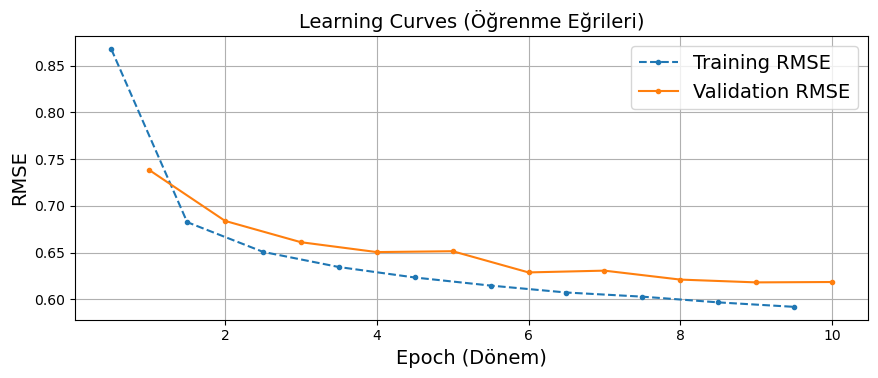

In [44]:
try:
    import torchmetrics

    torch.manual_seed(42)
    n_epochs = 10
    model2 = nn.Sequential(
        nn.Linear(n_features, 50), nn.ReLU(),
        nn.Linear(50, 40), nn.ReLU(),
        nn.Linear(40, 30), nn.ReLU(),
        nn.Linear(30, 1)
    ).to(device)
    optimizer2 = torch.optim.SGD(model2.parameters(), lr=0.01, momentum=0)
    rmse_m = torchmetrics.MeanSquaredError(squared=False).to(device)

    history = train2(model2, optimizer2, mse, rmse_m,
                     train_loader, valid_loader, n_epochs)

    # Learning Curves (Öğrenme Eğrileri) — Overfitting tespiti
    plt.figure(figsize=(9, 4))
    plt.plot(np.arange(n_epochs) + 0.5, history["train_metrics"], ".--", label="Training RMSE")
    plt.plot(np.arange(n_epochs) + 1.0, history["valid_metrics"], ".-",  label="Validation RMSE")
    plt.xlabel("Epoch (Dönem)")
    plt.ylabel("RMSE")
    plt.title("Learning Curves (Öğrenme Eğrileri)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("torchmetrics gerekli.")

---
<a id='8'></a>
## 8. Custom Module — Wide & Deep Architecture (Özel Modül)

`nn.Sequential` yeterli değilse `nn.Module` alt sınıfı oluşturulur.

**Wide & Deep mimarisi:**
- **Wide path (geniş yol):** özellikleri doğrudan output'a bağlar
- **Deep path (derin yol):** özellikler katmanlardan geçirilerek öğrenilir
- İkisi `concat` ile birleştirilir


### `nn.Module` Alt Sınıfı Yazma Kuralları

1. `nn.Module`'den miras al
2. `__init__` içinde `super().__init__()` çağır (**zorunlu**)
3. `forward(self, X)` metodunu tanımla — ileri geçiş mantığı buraya
4. Modülü hiçbir zaman `model.forward(X)` şeklinde değil, `model(X)` şeklinde çağır


In [45]:
class WideAndDeep(nn.Module):
    def __init__(self, n_features):
        super().__init__()   # nn.Module'ü başlat — ZORUNLU

        # Deep path (derin yol) — özellikler öğrenilir
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features, 40), nn.ReLU(),
            nn.Linear(40, 40), nn.ReLU()
        )

        # Output layer: wide (n_features) + deep (40) → 1
        self.output_layer = nn.Linear(40 + n_features, 1)

    def forward(self, X):
        deep_output    = self.deep_stack(X)                        # deep yol
        wide_and_deep  = torch.concat([X, deep_output], dim=1)    # birleştir (concat)
        return self.output_layer(wide_and_deep)                    # çıkış


torch.manual_seed(42)
wd_model = WideAndDeep(n_features).to(device)
print(wd_model)

WideAndDeep(
  (deep_stack): Sequential(
    (0): Linear(in_features=8, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=48, out_features=1, bias=True)
)


In [48]:
optimizer_wd = torch.optim.SGD(wd_model.parameters(), lr=0.002)
train(wd_model, optimizer_wd, criterion, train_loader, n_epochs=10)

val_loss = evaluate(wd_model, valid_loader, criterion)

print(f'\nValidation Loss (Wide & Deep): {val_loss:.4f}')


Epoch 1/10, Loss: 0.4590
Epoch 2/10, Loss: 0.4532
Epoch 3/10, Loss: 0.4477
Epoch 4/10, Loss: 0.4422
Epoch 5/10, Loss: 0.4375
Epoch 6/10, Loss: 0.4330
Epoch 7/10, Loss: 0.4279
Epoch 8/10, Loss: 0.4231
Epoch 9/10, Loss: 0.4188
Epoch 10/10, Loss: 0.4158

Validation Loss (Wide & Deep): 0.4586


---
<a id='s11'></a>
##  `WideAndDeepV2` — `forward()` İçinde Feature Split (Özellik Bölme)

`WideAndDeep`'ten farkı: tek bir `X` tensörü alır, `forward()` içinde kendisi böler.

- `X[:, :5]` → ilk 5 feature → **wide path** (geniş yol): basit, doğrudan bağlantı
- `X[:, 2:]` → 2. index'ten son → **deep path** (derin yol): birden fazla katmandan geçer

Bu yaklaşım dış kodda `TensorDataset`'i değiştirmeden kullanım kolaylığı sağlar.


In [49]:
class WideAndDeepV2(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # Deep path: feature[2:] girer (n_features - 2 giriş)
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),   # 6 → 50
            nn.Linear(50, 40),             nn.ReLU(),   # 50 → 40
            nn.Linear(40, 30),             nn.ReLU(),   # 40 → 30
        )
        # Output: wide (5) + deep (30) = 35 giriş
        self.output_layer = nn.Linear(30 + 5, 1)

    def forward(self, X):
        X_wide = X[:, :5]              # ilk 5 sütun — wide path
        X_deep = X[:, 2:]              # 2. index'ten itibaren — deep path
        deep_output   = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)   # birleştir
        return self.output_layer(wide_and_deep)


torch.manual_seed(42)
model_v2 = WideAndDeepV2(n_features).to(device)
print(model_v2)

# Normal (tek girişli) DataLoader ile kullanılabilir
optimizer_v2 = torch.optim.SGD(model_v2.parameters(), lr=0.002)
train(model_v2, optimizer_v2, mse, train_loader, n_epochs=3)

WideAndDeepV2(
  (deep_stack): Sequential(
    (0): Linear(in_features=6, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=30, bias=True)
    (5): ReLU()
  )
  (output_layer): Linear(in_features=35, out_features=1, bias=True)
)
Epoch 1/3, Loss: 1.5952
Epoch 2/3, Loss: 0.6240
Epoch 3/3, Loss: 0.5867


---
<a id='9'></a>
## 9. Multiple Inputs / Outputs (Çoklu Giriş / Çıkış)


### Birden Fazla Giriş — forward() Metoduna Çoklu Argüman


In [50]:
class WideAndDeepV3(nn.Module):
    def __init__(self, n_wide, n_deep):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_deep, 40), nn.ReLU(),
            nn.Linear(40, 40), nn.ReLU()
        )
        self.output_layer = nn.Linear(40 + n_wide, 1)

    def forward(self, X_wide, X_deep):   # iki ayrı tensor giriş
        deep_output   = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)


# Dataset: X_wide = ilk 5 feature, X_deep = son 6 feature
train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True)

# Training loop güncelleme:
wd3_model = WideAndDeepV3(n_wide=5, n_deep=6).to(device)
opt3 = torch.optim.SGD(wd3_model.parameters(), lr=0.002)

wd3_model.train()
for X_wide_b, X_deep_b, y_b in train_loader_wd:
    X_wide_b, X_deep_b, y_b = X_wide_b.to(device), X_deep_b.to(device), y_b.to(device)
    pred = wd3_model(X_wide_b, X_deep_b)   # iki ayrı giriş
    loss = criterion(pred, y_b)
    loss.backward()
    opt3.step()
    opt3.zero_grad()
    break   # demo için tek batch
print('İlk batch loss:', loss.item())

İlk batch loss: 5.648415565490723


### Python `*` ve `**` Operatörleriyle Dinamik Giriş

- `*X_batch_inputs` → kaç giriş olursa olsun çalışır
- `**inputs_dict` → dictionary'yi keyword arguments olarak açar


In [51]:
# * ile unpacking — kaç input olursa olsun çalışır
for *X_batch_inputs, y_batch in train_loader_wd:
    X_batch_inputs = [X.to(device) for X in X_batch_inputs]
    y_pred = wd3_model(*X_batch_inputs)   # liste elemanlarını argüman olarak geç
    break
print('* unpacking çalıştı, y_pred shape:', y_pred.shape)

* unpacking çalıştı, y_pred shape: torch.Size([32, 1])


### Named Inputs ile Custom Dataset (İsimli Girişler)

Büyük modellerde input sırası karışabilir. Dictionary kullanmak bunu önler.


In [52]:
class WideAndDeepDataset(torch.utils.data.Dataset):
    def __init__(self, X_wide, X_deep, y):
        self.X_wide = X_wide
        self.X_deep = X_deep
        self.y = y

    def __len__(self):
        return len(self.y)   # toplam örnek sayısı

    def __getitem__(self, idx):
        input_dict = {'X_wide': self.X_wide[idx], 'X_deep': self.X_deep[idx]}
        return input_dict, self.y[idx]   # (named inputs, target)


train_named = WideAndDeepDataset(X_train[:, :5], X_train[:, 2:], y_train)
loader_named = DataLoader(train_named, batch_size=32, shuffle=True)

for inputs, y_batch in loader_named:
    inputs = {name: X.to(device) for name, X in inputs.items()}
    y_batch = y_batch.to(device)
    y_pred = wd3_model(**inputs)   # dict'i keyword args olarak aç
    break
print('Named inputs ile forward çalıştı:', y_pred.shape)

Named inputs ile forward çalıştı: torch.Size([32, 1])


### Multiple Outputs (Çoklu Çıkış) — Auxiliary Output (Yardımcı Çıkış)

**Neden çoklu çıkış?**
- Aynı model farklı görevleri aynı anda öğrenir (multitask learning)
- **Auxiliary output** → regularization için: ağın belirli kısmının bağımsız öğrenmesini zorlar

Loss = `0.8 × main_loss + 0.2 × aux_loss` (ağırlık oranı hyperparameter)


In [53]:
class WideAndDeepV4(nn.Module):
    def __init__(self, n_wide, n_deep):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_deep, 40), nn.ReLU(),
            nn.Linear(40, 40), nn.ReLU()
        )
        self.output_layer     = nn.Linear(40 + n_wide, 1)   # ana çıkış
        self.aux_output_layer = nn.Linear(40, 1)             # yardımcı çıkış

    def forward(self, X_wide, X_deep):
        deep_output   = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        main_output   = self.output_layer(wide_and_deep)     # ana tahmin
        aux_output    = self.aux_output_layer(deep_output)   # yardımcı tahmin
        return main_output, aux_output   # ikisini de döndür


wd4_model = WideAndDeepV4(n_wide=5, n_deep=6).to(device)
opt4 = torch.optim.SGD(wd4_model.parameters(), lr=0.002)

# Training loop — çoklu çıkış
wd4_model.train()
for X_wide_b, X_deep_b, y_b in train_loader_wd:
    X_wide_b, X_deep_b, y_b = X_wide_b.to(device), X_deep_b.to(device), y_b.to(device)
    y_pred, y_pred_aux = wd4_model(X_wide_b, X_deep_b)   # iki çıkış
    main_loss = criterion(y_pred, y_b)
    aux_loss  = criterion(y_pred_aux, y_b)
    loss = 0.8 * main_loss + 0.2 * aux_loss              # ağırlıklı toplam
    loss.backward()
    opt4.step()
    opt4.zero_grad()
    break
print(f'Main loss: {main_loss.item():.4f}  Aux loss: {aux_loss.item():.4f}  Total: {loss.item():.4f}')

Main loss: 7.7143  Aux loss: 6.7050  Total: 7.5124


---
<a id='s12'></a>
##  `train_multi_in()` ve `evaluate_multi_in()` — Çoklu Giriş Loop'u

`WideAndDeepV3` gibi **ayrı wide ve deep input (giriş)** alan modeller için özel loop.

**`evaluate_multi_in()`:**
- `for X_batch_wide, X_batch_deep, y_batch in data_loader` → DataLoader 3 tensor döner

**`train_multi_in()`'in ayırt edici özelliği:**  
`for *X_batch_inputs, y_batch in train_loader` → Python'ın **starred unpacking** (yıldızlı açma) operatörü:
- `*X_batch_inputs` → son eleman `y_batch` hariç tüm elemanları liste olarak toplar
- `model(*X_batch_inputs)` → listeyi ayrı argüman olarak açar
- Böylece **kaç giriş olursa olsun** çalışan evrensel bir loop yazılır


In [54]:
class WideAndDeepV3(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)

    def forward(self, X_wide, X_deep):   # iki ayrı tensor kabul eder
        deep_output   = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

In [55]:
try:
    import torchmetrics

    # Dataset: (X_wide, X_deep, y) → 3 tensor döner
    train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
    valid_data_wd = TensorDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
    train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True)
    valid_loader_wd = DataLoader(valid_data_wd, batch_size=32)


    def evaluate_multi_in(model, data_loader, metric):
        model.eval()
        metric.reset()
        with torch.no_grad():
            for X_batch_wide, X_batch_deep, y_batch in data_loader:
                X_batch_wide = X_batch_wide.to(device)
                X_batch_deep = X_batch_deep.to(device)
                y_batch      = y_batch.to(device)
                y_pred = model(X_batch_wide, X_batch_deep)
                metric.update(y_pred, y_batch)
        return metric.compute()


    def train_multi_in(model, optimizer, criterion, metric,
                       train_loader, valid_loader, n_epochs):
        history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
        for epoch in range(n_epochs):
            total_loss = 0.
            metric.reset()

            # *** starred unpacking (yıldızlı açma) ***
            # *X_batch_inputs → [X_wide_batch, X_deep_batch] listesi
            for *X_batch_inputs, y_batch in train_loader:
                model.train()
                X_batch_inputs = [X.to(device) for X in X_batch_inputs]
                y_batch = y_batch.to(device)

                y_pred = model(*X_batch_inputs)   # listeyi ayrı arg olarak aç
                loss   = criterion(y_pred, y_batch)
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                metric.update(y_pred, y_batch)

            mean_loss    = total_loss / len(train_loader)
            valid_metric = evaluate_multi_in(model, valid_loader, metric).item()
            print(f"Epoch {epoch+1}/{n_epochs}  "
                  f"loss={mean_loss:.4f}  valid_RMSE={valid_metric:.4f}")
            history["train_losses"].append(mean_loss)
            history["valid_metrics"].append(valid_metric)
        return history


    torch.manual_seed(42)
    wd3_model = WideAndDeepV3(n_features).to(device)
    opt_wd3   = torch.optim.SGD(wd3_model.parameters(), lr=0.01, momentum=0)
    rmse_m2   = torchmetrics.MeanSquaredError(squared=False).to(device)

    history_wd3 = train_multi_in(wd3_model, opt_wd3, mse, rmse_m2,
                                  train_loader_wd, valid_loader_wd, n_epochs=5)

except ImportError:
    print("torchmetrics gerekli.")

Epoch 1/5  loss=0.7977  valid_RMSE=0.7515
Epoch 2/5  loss=0.5019  valid_RMSE=0.7258
Epoch 3/5  loss=0.4674  valid_RMSE=0.7044
Epoch 4/5  loss=0.4473  valid_RMSE=0.6945
Epoch 5/5  loss=0.4355  valid_RMSE=0.6819


---
<a id='s13'></a>
## `train_named()` ve `evaluate_named()` — Dict (Sözlük) Girişli Loop

**Named input (isimli giriş)** yaklaşımı: DataLoader her batch için `(dict, y)` döner.

**`evaluate_named()` içindeki kilit satırlar:**
```python
inputs = {name: X.to(device) for name, X in inputs.items()}   # dict comprehension
y_pred = model(X_wide=inputs["X_wide"], X_deep=inputs["X_deep"])  # açık isimli geçiş
```

**`train_named()` içindeki kilit satır:**
```python
y_pred = model(**inputs)   # ** ile dict → keyword arguments (isimli argümanlar)
```

`**inputs` → `model(X_wide=..., X_deep=...)` ile **tamamen eşdeğer** ama daha dinamik.  
Modelin `forward()` imzasıyla eşleştiği sürece her dict yapısında çalışır.


In [56]:
class WideAndDeepDataset(torch.utils.data.Dataset):
    def __init__(self, X_wide, X_deep, y):
        self.X_wide = X_wide
        self.X_deep = X_deep
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Her öğe: ({"X_wide": ..., "X_deep": ...}, y) döner
        input_dict = {"X_wide": self.X_wide[idx], "X_deep": self.X_deep[idx]}
        return input_dict, self.y[idx]

In [59]:
try:
    import torchmetrics

    train_data_named = WideAndDeepDataset(X_train[:, :5], X_train[:, 2:], y_train)
    valid_data_named = WideAndDeepDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
    train_loader_named = DataLoader(train_data_named, batch_size=32, shuffle=True)
    valid_loader_named = DataLoader(valid_data_named, batch_size=32)


    def evaluate_named(model, data_loader, metric):
        model.eval()
        metric.reset()
        with torch.no_grad():
            for inputs, y_batch in data_loader:
                # Dict'teki her tensörü device'a taşı
                inputs  = {name: X.to(device) for name, X in inputs.items()}
                y_batch = y_batch.to(device)
                y_pred  = model(X_wide=inputs["X_wide"], X_deep=inputs["X_deep"])
                metric.update(y_pred, y_batch)
        return metric.compute()


    def train_named(model, optimizer, criterion, metric,
                    train_loader, valid_loader, n_epochs):
        history = {"train_losses": [], "valid_metrics": []}
        for epoch in range(n_epochs):
            total_loss = 0.
            metric.reset()
            for inputs, y_batch in train_loader:
                model.train()
                inputs  = {name: X.to(device) for name, X in inputs.items()}
                y_batch = y_batch.to(device)
                y_pred  = model(**inputs)   # ** ile dict → keyword args
                loss    = criterion(y_pred, y_batch)
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                metric.update(y_pred, y_batch)
            mean_loss    = total_loss / len(train_loader)
            valid_metric = evaluate_named(model, valid_loader, metric).item()
            print(f"Epoch {epoch+1}/{n_epochs}  "
                  f"loss={mean_loss:.4f}  valid_RMSE={valid_metric:.4f}")
            history["train_losses"].append(mean_loss)
            history["valid_metrics"].append(valid_metric)
        return history


    torch.manual_seed(42)
    wd3_named = WideAndDeepV3(n_features).to(device)
    opt_named = torch.optim.SGD(wd3_named.parameters(), lr=0.01, momentum=0)
    rmse_m3   = torchmetrics.MeanSquaredError(squared=False).to(device)

    train_named(wd3_named, opt_named, mse, rmse_m3,
                train_loader_named, valid_loader_named, n_epochs=5)

except ImportError:
    print("torchmetrics gerekli.")

Epoch 1/5  loss=0.7977  valid_RMSE=0.7515
Epoch 2/5  loss=0.5019  valid_RMSE=0.7258
Epoch 3/5  loss=0.4674  valid_RMSE=0.7044
Epoch 4/5  loss=0.4473  valid_RMSE=0.6945
Epoch 5/5  loss=0.4355  valid_RMSE=0.6819


---
<a id='s14'></a>
## `train_multi_out()` ve `evaluate_multi_out()` — Çoklu Çıkış Loop'u

`WideAndDeepV4` gibi **iki çıkış (main + auxiliary)** döndüren modeller için.

**`evaluate_multi_out()`'un kilit satırı:**
```python
y_pred, _ = model(**inputs)   # auxiliary output (yardımcı çıkış) yok sayılır (_)
```
`_` → Python'da "bu değeri kullanmıyorum" konvansiyonu.

**`train_multi_out()`'un kilit satırları:**
```python
y_pred, y_pred_aux = model(**inputs)           # her iki çıkışı al
main_loss = criterion(y_pred, y_batch)         # ana loss
aux_loss  = criterion(y_pred_aux, y_batch)     # yardımcı loss
loss = 0.8 * main_loss + 0.2 * aux_loss        # ağırlıklı toplam
```
Ağırlık oranı (0.8/0.2) → hyperparameter; ana göreve daha fazla önem verir.


In [60]:
class WideAndDeepV4(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer     = nn.Linear(30 + 5, 1)   # ana çıkış
        self.aux_output_layer = nn.Linear(30, 1)        # yardımcı çıkış

    def forward(self, X_wide, X_deep):
        deep_output   = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        main_output   = self.output_layer(wide_and_deep)
        aux_output    = self.aux_output_layer(deep_output)   # deep path'ten ayrı
        return main_output, aux_output   # tuple olarak döner

In [61]:
try:
    import torchmetrics

    def evaluate_multi_out(model, data_loader, metric):
        model.eval()
        metric.reset()
        with torch.no_grad():
            for inputs, y_batch in data_loader:
                inputs  = {name: X.to(device) for name, X in inputs.items()}
                y_batch = y_batch.to(device)
                y_pred, _ = model(**inputs)   # _ → aux output yok sayıldı
                metric.update(y_pred, y_batch)
        return metric.compute()


    def train_multi_out(model, optimizer, criterion, metric,
                        train_loader, valid_loader, n_epochs):
        history = {"train_losses": [], "valid_metrics": []}
        for epoch in range(n_epochs):
            total_loss = 0.
            metric.reset()
            for inputs, y_batch in train_loader:
                model.train()
                inputs  = {name: X.to(device) for name, X in inputs.items()}
                y_batch = y_batch.to(device)

                y_pred, y_pred_aux = model(**inputs)      # iki çıkış
                main_loss = criterion(y_pred, y_batch)
                aux_loss  = criterion(y_pred_aux, y_batch)
                loss = 0.8 * main_loss + 0.2 * aux_loss  # ağırlıklı toplam

                total_loss += loss.item()
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                metric.update(y_pred, y_batch)

            mean_loss    = total_loss / len(train_loader)
            valid_metric = evaluate_multi_out(model, valid_loader, metric).item()
            print(f"Epoch {epoch+1}/{n_epochs}  "
                  f"loss={mean_loss:.4f}  valid_RMSE={valid_metric:.4f}")
        return history


    torch.manual_seed(42)
    wd4_model = WideAndDeepV4(n_features).to(device)
    opt_wd4   = torch.optim.SGD(wd4_model.parameters(), lr=0.01, momentum=0)
    rmse_m4   = torchmetrics.MeanSquaredError(squared=False).to(device)

    train_multi_out(wd4_model, opt_wd4, mse, rmse_m4,
                    train_loader_named, valid_loader_named, n_epochs=5)

except ImportError:
    print("torchmetrics gerekli.")

Epoch 1/5  loss=1.0034  valid_RMSE=0.7608
Epoch 2/5  loss=0.6075  valid_RMSE=0.7206
Epoch 3/5  loss=0.5289  valid_RMSE=0.7067
Epoch 4/5  loss=0.5001  valid_RMSE=0.7124
Epoch 5/5  loss=0.4731  valid_RMSE=0.6843


---
<a id='10'></a>
## 10. Image Classifier with TorchVision (Görüntü Sınıflandırıcı)

**Fashion MNIST** dataset: 10 sınıflı giysi görüntüleri (28×28 piksel, gri tonlama).


### TorchVision ile Dataset İndirme ve Transform

- `T.Compose()` → transform'ları sıraya dizer
- `T.ToImage()` → PIL/NumPy → TorchVision Image (Tensor alt sınıfı)
- `T.ToDtype(float32, scale=True)` → piksel değerlerini [0,255]'ten [0.0,1.0]'a ölçekler
- `random_split()` → dataset'i random böler (55K train, 5K valid)

> **Not:** TorchVision v2 transforms, v1'den daha hızlı ve kapsamlıdır.


### DataLoader ve Image Classifier Modeli

- `nn.Flatten()` → 28×28 görüntüyü 784 uzunluğunda vektöre düzleştirir
- Output layer **logit** (ham skor) döner — softmax uygulanmaz!
- `CrossEntropyLoss` içinde softmax uyguladığı için model logit çıkarmak yeterli


In [57]:
import torch
from torchvision import datasets
from torchvision.transforms import v2 as T
from torch.utils.data import random_split

# 1. Transform'ları sıraya dizme (T.Compose)
# v2 transformları daha hızlıdır ve 'ToImage' + 'ToDtype' kombinasyonunu önerir
transforms = T.Compose([
    T.ToImage(),                      # PIL görüntüsünü Torch Image formatına çevirir
    T.ToDtype(torch.float32, scale=True) # [0, 255] -> [0.0, 1.0] arasına çeker
])

# 2. Dataset İndirme (Örn: FashionMNIST)
dataset = datasets.FashionMNIST(
    root="data", 
    train=True, 
    download=True, 
    transform=transforms
)

# 3. random_split ile bölme (55K Train, 5K Validation)
train_set, valid_set = random_split(dataset, [55000, 5000])

print(f"Eğitim seti boyutu: {len(train_set)}")
print(f"Doğrulama seti boyutu: {len(valid_set)}")

Eğitim seti boyutu: 55000
Doğrulama seti boyutu: 5000


### CrossEntropyLoss ve Classification Training

| Loss Fonksiyonu | Kullanım Durumu |
|----------------|----------------|
| `nn.CrossEntropyLoss()` | Çok sınıflı sınıflandırma (multiclass) |
| `nn.BCEWithLogitsLoss()` | Binary sınıflandırma (0/1) |
| `nn.MSELoss()` | Regresyon |

**Label smoothing:** `nn.CrossEntropyLoss(label_smoothing=0.05)` → aşırı özgüveni azaltır.


In [ ]:
import torch.nn as nn

# 1. Model mimarisini tanımlayın (Örnek: Basit bir MLP)
class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(28*28, 10) # Örn: FashionMNIST için

    def forward(self, x):
        return self.fc(self.flatten(x))

# 2. Modeli oluşturun ve cihaza (CPU/GPU) gönderin
clf_model = SimpleClassifier().to(device)

# 3. Şimdi optimizer'ı tanımlayabilirsiniz
cross_entropy = nn.CrossEntropyLoss()
clf_optimizer = torch.optim.SGD(clf_model.parameters(), lr=0.01)

# Eğitim döngüsü...

In [ ]:
from torch.utils.data import DataLoader

# 'train_set' veya 'train_dataset' isminde bir veri setiniz olduğunu varsayılıyor
img_train_loader = DataLoader(
    dataset=train_set,   # Daha önce oluşturduğunuz eğitim veri seti
    batch_size=32,       # Her adımda modele kaç resim girecek?
    shuffle=True         # Veriyi her epoch başında karıştır (ezberlemeyi önler)
)


cross_entropy = nn.CrossEntropyLoss()   # içinde softmax var — model logit çıkarmalı
clf_optimizer = torch.optim.SGD(clf_model.parameters(), lr=0.01)

# Tek epoch eğitim (demo)
clf_model.train()
for X_batch, y_batch in img_train_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    logits = clf_model(X_batch)
    loss   = cross_entropy(logits, y_batch)
    loss.backward()
    clf_optimizer.step()
    clf_optimizer.zero_grad()
print(f'Son batch loss: {loss.item():.4f}')

### Tahmin ve Softmax — Olasılık Dönüşümü

- `F.softmax(logits, dim=1)` → her satırdaki logitleri olasılığa dönüştürür (toplamı 1)
- `.argmax(dim=1)` → en büyük değerin indeksi → sınıf etiketi
- `torch.topk(logits, k=4)` → ilk 4 tahmin


In [72]:
from torchvision import datasets
from torchvision.transforms import v2 as T

# 1. Transform tanımla (Görüntüyü Tensor'a çevirir ve 0-1 arasına ölçekler)
transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

# 2. Test verisini indir ve 'test_set' ismiyle kaydet
test_set = datasets.FashionMNIST(
    root="data", 
    train=False,    # ÖNEMLİ: Test seti için False olmalı
    download=True, 
    transform=transform
)

# 3. Şimdi hata aldığın DataLoader'ı tekrar çalıştırabilirsin
from torch.utils.data import DataLoader

img_test_loader = DataLoader(
    dataset=test_set, 
    batch_size=32, 
    shuffle=False
)

print(f"Test seti başarıyla yüklendi: {len(test_set)} örnek.")

Test seti başarıyla yüklendi: 10000 örnek.


In [73]:
import torch.nn.functional as F
from torch.utils.data import DataLoader

# 'test_set' isminde bir test veri setin olduğunu varsayıyoruz
img_test_loader = DataLoader(
    dataset=test_set, 
    batch_size=32,    # Tahmin için batch size çok kritik değildir ama 32-64 idealdir
    shuffle=False     # Test setini karıştırmaya (shuffle) gerek yoktur
)


class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

clf_model.eval()
X_sample, y_sample = next(iter(img_test_loader))
X_sample = X_sample[:3].to(device)

with torch.no_grad():
    logits = clf_model(X_sample)
    probas = F.softmax(logits, dim=1)         # olasılıklar
    preds  = logits.argmax(dim=1)             # tahmin edilen sınıflar

for i in range(3):
    print(f'Tahmin: {class_names[preds[i]]:12}  '
          f'Güven: {probas[i, preds[i]].item():.1%}')

Tahmin: Ankle boot    Güven: 57.4%
Tahmin: Pullover      Güven: 86.2%
Tahmin: Trouser       Güven: 99.9%


In [74]:
# Top-4 tahmin
top4_logits, top4_indices = torch.topk(logits, k=4, dim=1)
top4_probas = F.softmax(top4_logits, dim=1)

print('\nİlk örnek için Top-4 tahmin:')
for rank, (idx, prob) in enumerate(zip(top4_indices[0], top4_probas[0])):
    print(f'  {rank+1}. {class_names[idx.item()]:12}  {prob.item():.1%}')


İlk örnek için Top-4 tahmin:
  1. Ankle boot    57.6%
  2. Sneaker       23.0%
  3. Sandal        16.7%
  4. Bag           2.7%


---
<a id='s15'></a>
##  Parametre Sayısını Hesaplama — `numel()`

`.numel()` → bir tensördeki toplam eleman (element) sayısını döner.  
`sum([param.numel() for param in model.parameters()])` → modeldeki **tüm eğitilebilir parametre** sayısı.

Bu, model karmaşıklığını (complexity) hızlıca değerlendirmek için kullanılır.


In [93]:
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as T

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)

class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(n_inputs, n_hidden1)
        self.act1    = nn.ReLU()
        self.hidden2 = nn.Linear(n_hidden1, n_hidden2)
        self.act2    = nn.ReLU()
        self.output  = nn.Linear(n_hidden2, n_classes)

    def forward(self, X):
        return self.output(self.act2(self.hidden2(self.act1(self.hidden1(self.flatten(X))))))

torch.manual_seed(42)
model = ImageClassifier(n_inputs=1*28*28, n_hidden1=300,
                         n_hidden2=100, n_classes=10).to(device)

# Toplam parametre sayısı
total_params = sum([param.numel() for param in model.parameters()])
print(f"Toplam eğitilebilir parametre (total trainable parameters): {total_params:,}")

# Katman katman detay
for name, param in model.named_parameters():
    print(f"  {name:25s}  shape={str(param.shape):20s}  numel={param.numel():,}")

100%|██████████| 26421880/26421880 [02:29<00:00, 177244.09it/s]


Extracting datasets/FashionMNIST/raw/train-images-idx3-ubyte.gz to datasets/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 47941.13it/s]


Extracting datasets/FashionMNIST/raw/train-labels-idx1-ubyte.gz to datasets/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:04<00:00, 1005346.96it/s]


Extracting datasets/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to datasets/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 6012886.94it/s]

Extracting datasets/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to datasets/FashionMNIST/raw

Toplam eğitilebilir parametre (total trainable parameters): 266,610
  hidden1.weight             shape=torch.Size([300, 784])  numel=235,200
  hidden1.bias               shape=torch.Size([300])     numel=300
  hidden2.weight             shape=torch.Size([100, 300])  numel=30,000
  hidden2.bias               shape=torch.Size([100])     numel=100
  output.weight              shape=torch.Size([10, 100])  numel=1,000
  output.bias                shape=torch.Size([10])      numel=10


---
<a id='11'></a>
## 11. Hyperparameter Tuning with Optuna (Hiperparametre Ayarı)

**Optuna** → otomatik hyperparameter search (hiperparametre arama) kütüphanesi.  
TPE algoritması geçmiş denemelerden öğrenerek daha iyi bölgeleri arar.


In [75]:
# !pip install optuna  # Colab'da gerekirse

### Objective Function (Hedef Fonksiyon)

- `trial.suggest_float(name, low, high, log=True)` → log ölçekli float öneri
- `trial.suggest_int(name, low, high)` → integer öneri
- `trial.suggest_categorical(name, choices)` → kategori seçimi

`log=True` → küçük ve büyük değerleri eşit olasılıkla explore eder.


In [78]:
import torch
import torch.nn as nn
import optuna
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import v2 as T

# 1. Cihaz Yapılandırması
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Model Mimarisi (ImageClassifier)
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )
    
    def forward(self, x):
        return self.layers(x)

# 3. Veri Hazırlama (Dataset ve DataLoaderlar)
transform = T.Compose([
    T.ToImage(), 
    T.ToDtype(torch.float32, scale=True)
])

# Veriyi indir
full_train_set = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)

# Eğitim ve Doğrulama setlerine böl (55k-5k)
train_set, valid_set = random_split(full_train_set, [55000, 5000])

# Loader'ları tanımla (NameError almamak için isimlere dikkat!)
img_train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
img_valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False)

# 4. Optuna Objective Fonksiyonu
def objective(trial):
    # Hiperparametre önerileri
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    n_hidden      = trial.suggest_int('n_hidden', 20, 300)

    # Model ve optimizer
    model = ImageClassifier(
        n_inputs=784, n_hidden1=n_hidden, n_hidden2=n_hidden, n_classes=10
    ).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    # Eğitim (Hızlı demo için 1 epoch ve sadece 10 batch)
    model.train()
    batch_count = 0
    for X_b, y_b in img_train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits = model(X_b)
        loss = criterion(logits, y_b)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_count += 1
        if batch_count > 10: break 

    # Doğrulama (Accuracy hesaplama)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_v, y_v in img_valid_loader:
            X_v, y_v = X_v.to(device), y_v.to(device)
            preds = model(X_v).argmax(dim=1)
            correct += (preds == y_v).sum().item()
            total += y_v.size(0)
            break # Hız için validasyonun ilk batch'ine bakıyoruz
            
    return correct / total

# 5. Optuna Çalıştırma
try:
    torch.manual_seed(42)
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    study = optuna.create_study(direction='maximize')
    print("Optuna optimizasyonu başlıyor...")
    study.optimize(objective, n_trials=5) # n_trials deneme sayısını belirler

    print('\n🚀 Sonuçlar:')
    print('En iyi parametreler:', study.best_params)
    print('En iyi doğruluk oranı:', round(study.best_value, 4))

except ImportError:
    print('Hata: Optuna kütüphanesi yüklü değil. Kurmak için: !pip install optuna')

Optuna optimizasyonu başlıyor...

🚀 Sonuçlar:
En iyi parametreler: {'learning_rate': 0.0004467988195286608, 'n_hidden': 175}
En iyi doğruluk oranı: 0.2188


---
<a id='s17'></a>
## `functools.partial` ile Objective Fonksiyonu Sarmalama

Optuna'nın `optimize()` metodu yalnızca `trial` argümanı alan bir fonksiyon bekler.  
Ek argümanları geçmenin iki yolu:

**Yöntem 1 — Lambda (Anonim Fonksiyon):**
```python
objective_with_data = lambda trial: objective(trial, train_loader=..., valid_loader=...)
```

**Yöntem 2 — `functools.partial`:**
```python
from functools import partial
objective_with_data = partial(objective, train_loader=..., valid_loader=...)
```

`partial(f, **kwargs)` → `f` fonksiyonunun belirtilen argümanları önceden doldurulmuş  
yeni bir callable (çağrılabilir) nesnesi oluşturur.  
İkisi işlevsel olarak aynıdır; `partial` büyük projelerde daha okunabilir kabul edilir.


In [94]:
try:
    import optuna
    from functools import partial

    # Yöntem 1: lambda
    objective_lambda = lambda trial: objective(
        trial, train_loader=train_loader, valid_loader=valid_loader)

    # Yöntem 2: functools.partial — daha Pythonic
    objective_with_data = partial(objective,
                                  train_loader=train_loader,
                                  valid_loader=valid_loader)

    print("lambda ile tip:", type(objective_lambda))
    print("partial ile tip:", type(objective_with_data))
    print("İkisi de tek argümanla çağrılabilir: f(trial)")

except ImportError:
    print("optuna gerekli.")

lambda ile tip: <class 'function'>
partial ile tip: <class 'functools.partial'>
İkisi de tek argümanla çağrılabilir: f(trial)


### Pruning (Erken Kesme) — Kötü Trial'ları Durdurma

`MedianPruner` → geçmiş trial'ların medyan performansının altındakileri keser.


In [79]:
try:
    import optuna

    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,   # pruning öncesi min trial sayısı
        n_warmup_steps=0,     # her trial'da pruning'siz geçecek epoch
        interval_steps=1      # kaç epoch'ta bir kontrol
    )

    # Objective içinde her epoch'tan sonra:
    # trial.report(validation_accuracy, epoch)
    # if trial.should_prune():
    #     raise optuna.TrialPruned()

    print('MedianPruner hazır:', pruner)
except ImportError:
    print('Optuna kurulu değil.')

MedianPruner hazır: <optuna.pruners._median.MedianPruner object at 0x7fa4d2500af0>


In [99]:
import torch
import torch.nn as nn

def objective_with_data(trial, train_loader, valid_loader):
    # 1. Hiperparametreleri öner
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 32, 256)

    # 2. Model, Optimizer ve Criterion (Örnek mimari)
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, 10)
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # 3. Eğitim Döngüsü (Demo için 1 epoch)
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx > 50: break # Hızlı sonuç için sınırlama

    # 4. Doğrulama (Accuracy hesaplama kısmı - Hatanın çözümü)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in valid_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            break # Hız için sadece bir batch

    # İŞTE BURASI: Artık 'accuracy' tanımlı
    accuracy = correct / total
    return accuracy 

# --- Çalıştırma Kısmı ---
study.optimize(
    lambda t: objective_with_data(t, img_train_loader, img_valid_loader), 
    n_trials=3
)

---
<a id='12'></a>
## 12. Saving & Loading Models (Model Kaydetme ve Yükleme)


### Yöntem 1: Tam Modeli Kaydetme

Basit ama taşınabilirlik düşük — aynı class kodu gerektirir.


In [80]:
# Kaydet
torch.save(clf_model, 'my_fashion_mnist.pt')
print('Model kaydedildi: my_fashion_mnist.pt')

# Yükle (custom class kod ortamda bulunmalı!)
loaded_model = torch.load('my_fashion_mnist.pt', weights_only=False)
print('Model yüklendi:', type(loaded_model))

Model kaydedildi: my_fashion_mnist.pt
Model yüklendi: <class '__main__.SimpleClassifier'>


### Yöntem 2: state_dict Kaydetme — ÖNERİLEN

`state_dict()` → modelin tüm parametrelerini `OrderedDict` olarak döner.  
Sadece ağırlıklar kaydedilir; mimariden bağımsız ve daha taşınabilir.


In [85]:
import torch
import torch.nn as nn

# --- DEĞİŞMESİ GEREKEN KISIM (Mimariyi Kayıt Dosyasına Uygun Hale Getirdik) ---
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.flatten = nn.Flatten()
        # Hata mesajındaki "fc" ismine sadık kalıyoruz
        self.fc = nn.Linear(n_inputs, n_classes) 
        
    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)
# ----------------------------------------------------------------------------

# Sadece ağırlıkları kaydet
torch.save(clf_model.state_dict(), 'my_fashion_mnist_weights.pt')
print('Ağırlıklar kaydedildi.')

# Yükle: önce aynı modeli oluştur, sonra ağırlıkları yükle
torch.manual_seed(0)
new_model = ImageClassifier(n_inputs=784, n_hidden1=100,
                             n_hidden2=100, n_classes=10).to(device)



new_model.load_state_dict(torch.load('my_fashion_mnist_weights.pt',
                                      map_location=device))
new_model.eval()
print('Ağırlıklar yüklendi.')

Ağırlıklar kaydedildi.
Ağırlıklar yüklendi.


### Yöntem 3: Checkpoint (Kontrol Noktası) — Eğitimi Sürdürmek İçin

Model + optimizer state + epoch bilgisini kaydeder; eğitimi yarıdan devam etmek için.


In [86]:
# Checkpoint kaydet
checkpoint = {
    'epoch': 5,
    'model_state_dict':     clf_model.state_dict(),
    'optimizer_state_dict': clf_optimizer.state_dict(),
    'loss': 0.42
}
torch.save(checkpoint, 'checkpoint.pt')
print('Checkpoint kaydedildi.')

# Checkpoint geri yükle
ckpt = torch.load('checkpoint.pt', map_location=device)
resume_model = ImageClassifier(784, 100, 100, 10).to(device)
resume_optimizer = torch.optim.SGD(resume_model.parameters(), lr=0.01)

resume_model.load_state_dict(ckpt['model_state_dict'])
resume_optimizer.load_state_dict(ckpt['optimizer_state_dict'])
start_epoch = ckpt['epoch']
print(f'Eğitim {start_epoch}. epoch\'tan devam edecek.')

Checkpoint kaydedildi.
Eğitim 5. epoch'tan devam edecek.


---
<a id='13'></a>
## 13. TorchScript & `torch.compile` (Derleme ve Optimizasyon)

**TorchScript** → modeli Python'dan bağımsız, statik bir formata derler.  
**`torch.compile`** → PyTorch 2.0+ ile gelen modern, JIT tabanlı derleme.


### TorchScript — Tracing (İzleme)

`torch.jit.trace()` → modeli bir örnek input ile çalıştırır ve işlemleri kaydeder.  
**Sınır:** Python'ın dinamik control flow (`if`, `for`) girdiye bağlıysa doğru çalışmayabilir.


In [88]:
# 1. Önce modeli CPU'ya çekiyoruz (Tracing uyumluluğu için)
clf_model.cpu()
example_input = torch.rand(1, 1, 28, 28) # CPU'da kalsın

# 2. Tracing işlemini gerçekleştiriyoruz
traced_model = torch.jit.trace(clf_model, example_input)
print('Traced model tipi:', type(traced_model))

# 3. Modelleri tekrar eski cihazına (MPS/GPU) geri gönderiyoruz
clf_model.to(device)
traced_model.to(device)
example_input = example_input.to(device)

# 4. Çıktı karşılaştırması
with torch.no_grad():
    original_out = clf_model(example_input)
    traced_out   = traced_model(example_input)

print('Çıktılar eşit mi?', torch.allclose(original_out, traced_out))

Traced model tipi: <class 'torch.jit._trace.TopLevelTracedModule'>
Çıktılar eşit mi? True


### TorchScript — Scripting (Betikleme)

`torch.jit.script()` → Python kodunu analiz eder; `if/loop` yapılarını da doğru işler.  
Tracing'den daha güvenilir ama bazı Python özelliklerini desteklemez.


In [89]:
# Scripting ile TorchScript
scripted_model = torch.jit.script(clf_model)
print('Scripted model tipi:', type(scripted_model))

Scripted model tipi: <class 'torch.jit._script.RecursiveScriptModule'>


### Optimizasyon, Kaydetme ve Yükleme


In [90]:
# Inference için optimize et
optimized_model = torch.jit.optimize_for_inference(traced_model)

# Kaydet ve yükle
traced_model.save('my_fashion_mnist_torchscript.pt')
loaded_ts = torch.jit.load('my_fashion_mnist_torchscript.pt')
print('TorchScript modeli kaydedildi ve yüklendi.')

TorchScript modeli kaydedildi ve yüklendi.


### `torch.compile()` — Modern JIT Derleme (PyTorch 2.0+)

| Özellik | TorchScript | `torch.compile` |
|---------|-------------|------------------|
| Derleme zamanı | AOT (Ahead-of-Time) | JIT (Just-in-Time) |
| Python desteği | Kısıtlı | Tam |
| Geliştirme durumu | Bakım modu | Aktif geliştirme |
| Kullanım kolaylığı | Orta | Çok kolay |

**Dahili bileşenler:**
- **TorchDynamo (Dynamo)** → Python bytecode'u yakalar
- **TorchInductor** → Nvidia için Triton kodu, CPU için OpenMP üretir


In [91]:
# torch.compile — tek satırda!
compiled_model = torch.compile(clf_model)

# Normal şekilde kullan — ilk çağrıda JIT derlenir
with torch.no_grad():
    out = compiled_model(example_input)
print('Compiled model çıktı shape:', out.shape)
print('torch.compile başarıyla çalıştı!')

Compiled model çıktı shape: torch.Size([1, 10])
torch.compile başarıyla çalıştı!


Process ForkProcess-7:
Process ForkProcess-2:
Process ForkProcess-1:
Process ForkProcess-4:
Process ForkProcess-6:
Process ForkProcess-8:
Process ForkProcess-5:
Process ForkProcess-3:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/livanurkaranf




## 14. Exercises — Alıştırmalar

-----

**1.** PyTorch, NumPy'a kıyasla hangi ek özellikleri sunar?  

**2.** `torch.exp()` ile `torch.exp_()` arasındaki fark nedir? (`relu()` ve `relu_()` için de düşünün)  

**3.** GPU'da tensor oluşturmanın iki yolu nedir?  

**4.** Autograd kullanmadan tensor hesaplaması yapmanın üç yolu nedir?  

**5.** Aşağıdaki kod `RuntimeError` verir mi?  
```python
t = torch.tensor(2.0, requires_grad=True)
z = t.cos().exp_()   # in-place op
z.backward()
```

**6.** `Linear(100, 200)` modülü kaç nörona sahip? `weight` ve `bias` shape'i nedir?  

**7.** PyTorch training loop'unun ana adımları nelerdir?  

**8.** Optimizer neden model GPU'ya taşındıktan **sonra** oluşturulmalıdır?  

**9.** GPU hızlandırma için `DataLoader`'da hangi seçenekler ayarlanmalıdır?  

**10.** PyTorch'un sunduğu başlıca classification loss fonksiyonları nelerdir?  

**11.** `model.train()` ve `model.eval()` çağırmak neden önemlidir?  

**12.** `torch.jit.trace()` ile `torch.jit.script()` arasındaki fark nedir?  


**1.** PyTorch, birçok yönden NumPy'a benzer, ancak bazı ekstra özellikler sunar. Başlıcaları şunlardır:

Auto-differentiation (otomatik türev alma)

Hardware accelerators (donanım hızlandırıcıları) desteği

Optimizer'lar (eniyileme algoritmaları) ve kullanıma hazır neural net (sinir ağı) bileşenleri içerir.

**2.** torch.exp() girdi tensor'ünün (tensörünün) bir kopyasını döndürürken, torch.exp_() onu in-place (yerinde/mevcut bellek üzerinde) değiştirir. Benzer şekilde, torch.relu() bir kopya döndürürken torch.relu_() in-place (yerinde) değişiklik yapar.

**3.** GPU üzerinde yeni bir tensor oluşturmak için şu yöntemlerden birini kullanabilirsin:

torch.tensor(), torch.rand() veya yeni tensor'ler oluşturan diğer fonksiyonları çağırırken device (cihaz) argümanını ayarla. Örneğin, torch.randn(10, device="cuda") CUDA GPU üzerinde 10 rastgele elemanlı yeni bir tensor oluşturur.

CPU üzerinde yeni bir tensor oluştur, ardından to() metodunu çağırarak onu GPU'ya aktar, örneğin torch.randn(10).to("cuda"). Ancak, tensor'ü doğrudan GPU üzerinde oluşturmak daha verimlidir.

ones_like() ve zeros_like() gibi *_like() fonksiyonları, başka bir tensor ile aynı cihazda yeni bir tensor oluşturur. Ayrıca aynı data type'ı (veri tipini) kullanırlar.

Son olarak, GPU üzerinde bulunan bir tensor üzerinde bir işlem yürütürsen, sonuç genellikle GPU üzerinde yeni bir tensor olacaktır (torch.exp_() gibi bir in-place işlemi kullanmadığın sürece).

**4.** Autograd (otomatik türev) kullanmadan tensor hesaplamaları yapmanın üç yolu şunlardır:

requires_grad=False (varsayılan değerdir) ile oluşturulan tensor'leri manipüle et.

Hesaplamaları bir with torch.no_grad(): bloğu içinde çalıştır.

Autograd olmadan manipüle etmek istediğin tensor üzerinde detach() metodunu çağır.

**5.** Her durumda ne olduğu aşağıda açıklanmıştır:

İlk kod örneği sorunsuz çalışacaktır, bir RuntimeError (çalışma zamanı hatası) vermeyecektir: Gerçekten de, cos() metodu yeni bir (non-leaf / yaprak olmayan) tensor oluşturur, ardından exp_() onu in-place (yerinde) değiştirir. Backward pass (geriye doğru geçiş) sırasında, PyTorch exp_() işlemi üzerinden backpropagate (geriye yayılım) yapabilir çünkü exp(x)'in türevi exp(x)'tir; bu yüzden PyTorch'un girdi x'in ne olduğunu bilmesine gerek yoktur, backward pass sırasında sadece forward pass'in (ileriye doğru geçişin) çıktısını (yani exp(x)) kullanabilir.

Eğer z = t.cos().exp_() ifadesini z = t.cos_().exp() ile değiştirirsen, o satırda bir RuntimeError alırsın ("grad gerektiren bir leaf Variable in-place işleminde kullanılıyor"). Gerçekten de, t bir leaf tensor'dür (yaprak tensör; doğrudan kullanıcı tarafından oluşturulmuştur, herhangi bir hesaplamanın sonucu değildir) ve requires_grad=True olan bir leaf tensor üzerinde in-place bir işlem uygulayamazsın.

Eğer z = t.cos().exp_() ifadesini z = t.exp().cos_() ile değiştirirsen, backward pass sırasında bir RuntimeError alırsın ("gradyan hesaplaması için gereken değişkenlerden biri in-place bir işlemle değiştirildi"). Gerçekten de, exp() işlemi, exp(t)'nin türevinin exp(t) olduğu gerçeğine dayanır, bu nedenle backward pass için t tensor'ünü saklamasına gerek yoktur, bunun yerine sadece t.exp() tarafından döndürülen tensor'ü (buna e diyelim) kullanabileceği gerçeğine güvenir. Buraya kadar her şey yolunda. Ancak cos_() işlemini çağırdığımızda, backward pass sırasında girdisine ihtiyacı olacağını bilir (çünkü cos(e)'nin türevi –sin(e)'dir), bu yüzden girdi tensor'ü e'nin bir kopyasını saklar. Daha sonra, orijinal e'yi in-place olarak değiştirmeye çalışır ve bunu yaparken bu tensor'ün backward pass için başka bir işlem (exp()) tarafından gerekli olduğunu fark eder, böylece bir şeylerin ters gittiğini anlar ve bir RuntimeError fırlatır.

İkinci kod örneği backpropogation (geriye yayılım) sırasında bir RuntimeError ile başarısız olacaktır. Bir öncekine çok benzer bir hatadır: cos() işlemi girdi tensor'ü v'nin bir referansını saklar, çünkü v backward pass sırasında gerekli olacaktır. Gerçekten de, cos(v)'nin türevi –sin(v)'dir, bu yüzden v'yi kaydetmemiz gerekir. Sonra, sin_() işlemi girdisi v'nin bir kopyasını oluşturur (in-place bir işlem olduğu için sadece bir referansı korumakla kalmayıp bir kopya oluşturması gerektiğini bilir), ardından orijinal v'yi değiştirmeye devam eder, ancak bu tensor cos(v)'nin gradyanını hesaplamak için gereklidir, bu yüzden PyTorch bir RuntimeError fırlatır.

Eğer w = v.cos() * v.sin_() ifadesini w = v.cos_() * v.sin() ile değiştirirsen, artık herhangi bir RuntimeError olmaz. Gerçekten de, cos_() işlemi, backward pass sırasında –sin(v)'yi hesaplayabilmek için girdisi v'nin bir kopyasını oluşturur. sin() işlemi in-place değildir, bu yüzden girdisi v'ye bir referans tutar, kopya değil. Backprop daha sonra sorunsuz çalışır. Ancak, burada bir bit yeniği var: sin() işlemi çalıştığında, girdisi v artık 3.0'a eşit değildir, bunun yerine cos(3.0)'a eşittir çünkü cos_() v'yi in-place (yerinde) değiştirmiştir. Sonuç olarak, w = v.cos() * v.sin_(), w = v.cos_() * v.sin() ile aynı sonucu vermez. İlki cos(3) * sin(3) hesaplarken ikincisi cos(3) * sin(cos(3)) hesaplar. Ve tabii ki gradyanlar da değişir. Bu yüzden in-place işlemlerde çok dikkatli olmalısın: kodunu hızlandırabilirler elbette, ama aynı zamanda sessizce yanlış çalışmasına da neden olabilirler.

**6.** Bir Linear(100, 200) module (modülü) 200 neuron'a (nöron) sahiptir: her çıktı için bir tane. weight (ağırlık) tensor'ü [200, 100] shape'ine (şekline/boyutuna) sahiptir ve bias (sapma) parametresi [200] shape'ine sahiptir. Girdilerinin örneğin [32, 100] veya [32, 64, 100] gibi [..., 100] shape'ine sahip olmasını bekler. Son boyut hariç tüm boyutları bağımsız olarak ele alır. Çıktı shape'i, son boyutun 200 ile değiştirilmesi dışında girdi shape'i ile aynıdır. Örneğin, girdi shape'i [32, 64, 100] ise, çıktı shape'i [32, 64, 200] olur.

**7.** Bir PyTorch training loop'unun (eğitim döngüsünün) ana adımları şunlardır:

Training set'ten (eğitim setinden) bir batch of samples (örnek yığını/paketi) hazırla. Bunun için bir DataLoader (veri yükleyici) kullanabilirsin.

İsteğe bağlı olarak bu örnekleri GPU'ya aktar (genellikle X_batch.to(device) ve y_batch.to(device) kullanarak).

Girdileri modelden geçir (forward pass), örneğin y_pred = model(X_batch).

Loss'u (kayıp/hata) hesapla, örneğin loss = criterion(y_pred, y_true).

loss.backward() kullanarak loss üzerinden backpropagate (geriye yayılım) yap.

Bir optimizer step (eniyileme adımı) gerçekleştir: optimizer.step().

Gradients'i (gradyanları) sıfırla: optimizer.zero_grad() (alternatif olarak, bunu backward pass'ten önce de yapabilirsin, eğer eğitim döngüsü başlamadan önce gradyanlar sıfır değilse bu daha güvenli olabilir).

Tüm training loop (eğitim döngüsü) genellikle epoch'lara (dönemlere) bölünür, ancak bu isteğe bağlıdır.

**8.** Optimizer'ı model GPU'ya taşındıktan sonra oluşturman önerilir çünkü çoğu optimizer bazı internal state'lere (iç durumlara) sahiptir ve bu state genellikle model parametreleriyle aynı device (cihaz) üzerinde tahsis edilir.

**9.** Bir GPU kullanırken training'i (eğitimi) hızlandırmak için genel olarak şu DataLoader seçeneklerini ayarlamalısın:

Data loader'ın num_workers argümanını veri yükleme ve ön işleme için kullanmak istediğin process (işlem/süreç) sayısına ayarla. Bu, GPU mevcut batch üzerinde çalışırken bir sonraki batch'leri CPU üzerinde pre-fetching (önceden getirerek) yaparak genellikle eğitimi hızlandıracaktır. Optimal sayı platformuna, donanımına ve iş yüküne bağlıdır, bu yüzden farklı değerlerle denemeler yapmalısın.

Her bir worker'ın (işçinin) önceden getireceği batch sayısını kontrol etmek için data loader'ın prefetch_factor argümanını ayarla.

Eğer worker'ları başlatmak (spawning) ve senkronize etmek çok fazla overhead (ek yük) yaratıyorsa (özellikle Windows'ta), worker'ları epoch'lar boyunca yeniden kullanmak için persistent_workers=True ayarlamayı deneyebilirsin.

**10.** PyTorch tarafından sağlanan ana classification losses (sınıflandırma kayıpları) şunlardır:

nn.CrossEntropyLoss: Verimli ve sayısal olarak stabil olduğu için multiclass classification (çok sınıflı sınıflandırma) için genellikle kullanmak isteyeceğin kayıptır. Bu kayıp doğrudan probabilities (olasılıklar) üzerinde değil, logits (ham model çıktıları) üzerinde çalışır, bu yüzden modelin çıktı katmanında softmax activation function (aktivasyon fonksiyonu) içermemelidir. Sonuç olarak, olasılıkları tahmin etmen gerektiğinde, modelin çıktısı olan logit'ler üzerinde F.softmax() fonksiyonunu çağırmalısın.

nn.BCEWithLogitsLoss (BCE, binary cross-entropy anlamına gelir): nn.CrossEntropyLoss ile aynı nedenden dolayı binary classification (ikili sınıflandırma) için genellikle kullanmak isteyeceğin kayıptır. Tıpkı önceki kayıp gibi, doğrudan logit'lerle çalışır, bu yüzden modelin çıktı katmanında sigmoid activation function içermemelidir. Olasılıkları tahmin etmen gerektiğinde, modelin çıktısı olan logit'ler üzerinde F.sigmoid() fonksiyonunu çağırmalısın. Bazı kişilerin çok küçük bir hesaplama ve bellek maliyeti pahasına, sınıf sayısından bağımsız olarak kodu daha tutarlı hale getirdiği için ikili sınıflandırma için bile nn.CrossEntropyLoss kullanmayı tercih ettiğini unutma.

nn.NLLLoss (NLL, negative log-likelihood / negatif log-olabilirlik anlamına gelir): Multiclass classification için nn.CrossEntropyLoss'a bir alternatiftir. Bunu kullanmak için, modelin logit'ler yerine log probabilities (log olasılıkları) üretmesi gerekir. Bu, nn.LogSoftmax() veya F.log_softmax() kullanılarak yapılabilir. Bu yaklaşım CrossEntropyLoss kullanmaktan biraz daha yavaştır, ancak modelinin logit'ler yerine log olasılıkları üretmesini istiyorsan veya nihai loss'u hesaplamadan önce olasılık dağılımında ince ayar yapmak istediğinde yararlı olabilir (gerçekten de bazen logit'ler yerine log olasılıklarını değiştirmek daha kolaydır). Olasılıkları tahmin etmen gerektiğinde, modelin çıktıları üzerinde torch.exp() çağırmalısın.

nn.BCELoss: Bu kayıp, binary classification için nn.BCEWithLogitsLoss'a bir alternatiftir. Modelinin logit'ler yerine olasılıklar ürettiğini varsayar, bu nedenle modelinin çıktı katmanı sigmoid aktivasyon fonksiyonunu kullanmalıdır. Modelinin doğrudan olasılıklar üretmesini istiyorsan bu kullanışlı olabilir, ancak BCEWithLogitsLoss kullanmaktan biraz daha yavaş ve sayısal olarak daha az stabildir.

**11.** Eğitimden önce model.train() ve değerlendirmeden önce model.eval() çağırmak önemlidir çünkü bazı layer'lar (katmanlar) (örneğin nn.Dropout, nn.BatchNorm1d veya nn.BatchNorm2d) training (eğitim) ve evaluation (değerlendirme) sırasında aynı şekilde davranmazlar, bu nedenle modele hangi modda çalışması gerektiğini söylemeliyiz.

**12.** Hem torch.jit.trace() hem de torch.jit.script(), modelinin computation graph'ını (hesaplama grafiğini) yakalamaya ve onu optimize edilebilen, kaydedilebilen ve çeşitli platformlara dağıtılabilen (deploy) TorchScript koduna dönüştürmeye çalışır. Ancak bu fonksiyonlar çok farklı çalışır:

torch.jit.trace() fonksiyonu, modelini hangi işlemlerin yürütüldüğünü yakalayan bir tracing tensor (izleme tensörü) ile çalıştırır. Oldukça basittir ve basit modeller için iyi çalışır, ancak conditionals (koşullu ifadeleri, örn. if, elif, else, match) yakalayamaz: sadece tracing sırasında gerçekten yürütülen koşul dalını yakalar. Benzer şekilde, eğer modelin bir loop (döngü, örn. for veya while) içeriyorsa, tracing döngünün kendisini yakalamaz, sadece tekrarlanan işlemleri yakalar.

torch.jit.script() fonksiyonu aslında TorchScript kodu üretmek için Python kodunu ayrıştırır (parses). Bu, (koşullar tensor olduğu sürece) koşullu ifadeleri algılamasını ve ayrıca döngüleri yakalamasını sağlar. Ancak, Python'un sadece bir alt kümesiyle çalışır: global variables (küresel değişkenler), Python generators (yield), karmaşık list comprehensions (liste üreteçleri), değişken uzunluklu fonksiyon argümanları (*args veya **kwargs) veya match ifadelerini kullanamazsın. Dahası, type'lar (tipler) sabit olmalıdır (bir fonksiyon bazı durumlarda bir tamsayı, diğerlerinde bir ondalıklı sayı döndüremez) ve diğer fonksiyonları yalnızca bu kurallara uyuyorlarsa çağırabilirsin, yani standart kütüphane, üçüncü taraf kütüphaneler vb. desteklenmez.

---
<a id='s20'></a>
## Exercise 13 — Autograd ile Gradyan Hesaplama (3 Farklı Yöntem)

**f(x, y) = sin(x²·y)** fonksiyonunun **(x, y) = (1.2, 3.4)** noktasındaki gradyanı.

Matematiksel kısmi türevler:
- ∂f/∂x = 2xy·cos(x²y)
- ∂f/∂y = x²·cos(x²y)


### Yöntem 1 — Skaler Değişkenler ile Autograd

In [100]:
def f(x, y):
    return torch.sin(x ** 2 * y)

# requires_grad=True → PyTorch bu tensörleri izler
x = torch.tensor(1.2, requires_grad=True)
y = torch.tensor(3.4, requires_grad=True)

result = f(x, y)
result.backward()   # chain rule ile gradyanları hesapla

print(f"f(1.2, 3.4) = {result.item():.6f}")
print(f"∂f/∂x = {x.grad.item():.6f}")
print(f"∂f/∂y = {y.grad.item():.6f}")

f(1.2, 3.4) = -0.983191
∂f/∂x = 1.489865
∂f/∂y = 0.262917


### Yöntem 2 — Vektörize (Vectorized) Implementasyon

`f_vec(v)` → `v = [x, y]` şeklinde tek bir vektör alır.  
`result.backward()` → `v.grad` içinde gradyan vektörünü döner.  
Bu yaklaşım, yüksek boyutlu optimizasyon problemleri için daha ölçeklenebilir (scalable).


In [101]:
def f_vec(v):
    return torch.sin(v[0] ** 2 * v[1])

v = torch.tensor([1.2, 3.4], requires_grad=True)
result = f_vec(v)
result.backward()

print(f"Gradyan vektörü v.grad: {v.grad}")
print(f"∂f/∂x = {v.grad[0].item():.6f}")
print(f"∂f/∂y = {v.grad[1].item():.6f}")

Gradyan vektörü v.grad: tensor([1.4899, 0.2629])
∂f/∂x = 1.489865
∂f/∂y = 0.262917


### Yöntem 3 — Nümerik Doğrulama (Finite Differences / Sonlu Farklar)

**Finite differences (sonlu farklar)** → türevin nümerik yaklaşımı:

$$\frac{\partial f}{\partial x} \approx \frac{f(x + \epsilon, y) - f(x, y)}{\epsilon}$$

`eps = 0.00005` → çok küçük bir adım; sonuç analitik türeve yaklaşmalı.  
Bu yöntem autograd'ın doğruluğunu bağımsız olarak doğrulamak için kullanılır.


In [102]:
eps = 0.00005

# no_grad gereksiz ama iyi pratik
with torch.no_grad():
    df_dx_numeric = (f(x + eps, y) - f(x, y)) / eps
    df_dy_numeric = (f(x, y + eps) - f(x, y)) / eps

print(f"Nümerik ∂f/∂x ≈ {df_dx_numeric.item():.6f}")
print(f"Nümerik ∂f/∂y ≈ {df_dy_numeric.item():.6f}")
print(f"(Autograd ile fark: {abs(df_dx_numeric.item() - x.grad.item()):.2e})")

Nümerik ∂f/∂x ≈ 1.490116
Nümerik ∂f/∂y ≈ 0.262260
(Autograd ile fark: 2.51e-04)


### Yöntem 4 — Analitik (Matematiksel) Hesap

In [103]:
# Türev formüllerini doğrudan uygula
with torch.no_grad():
    df_dx_analytic = 2 * x * y * torch.cos(x**2 * y)
    df_dy_analytic = x ** 2 * torch.cos(x**2 * y)

print(f"Analitik ∂f/∂x = {df_dx_analytic.item():.6f}")
print(f"Analitik ∂f/∂y = {df_dy_analytic.item():.6f}")
print(f"Autograd ile tam eşleşiyor mu? {torch.isclose(df_dx_analytic, x.grad)}")

Analitik ∂f/∂x = 1.489865
Analitik ∂f/∂y = 0.262917
Autograd ile tam eşleşiyor mu? True


---
<a id='s21'></a>
## Exercise 14 — `Dense`, `Dense2`, `Dense3` Modülleri

`nn.Linear + nn.ReLU` kombinasyonunu taklit eden üç farklı implementasyon.


### `Dense` — nn.Linear + nn.ReLU Kullanan Versiyon

En basit yaklaşım: standart PyTorch katmanlarını birleştirir.  
`self.relu` → `nn.ReLU()` modül olarak saklanır; bu sayede `dense.relu(...)` şeklinde erişilebilir.


In [104]:
import torch.nn.functional as F

class Dense(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.relu   = nn.ReLU()

    def forward(self, X):
        return self.relu(self.linear(X))


torch.manual_seed(42)
dense = Dense(3, 5)
X_test_dense = torch.randn(2, 3)
y_pred = dense(X_test_dense)
print("Dense çıktı shape:", y_pred.shape)

# Manuel doğrulama: nn.Linear(X) → ReLU uygulaması
y_pred_check = dense.relu(X_test_dense @ dense.linear.weight.T + dense.linear.bias)
print("Manuel hesapla eşleşiyor mu?", torch.allclose(y_pred, y_pred_check))

Dense çıktı shape: torch.Size([2, 5])
Manuel hesapla eşleşiyor mu? True


### `Dense2` — `nn.Parameter` ve `F.relu` Kullanan Versiyon

`nn.Linear` kullanmadan, parametreleri **manuel olarak** tanımlar.

- `nn.Parameter(torch.randn(...))` → random normal dağılımla başlatılmış eğitilebilir parametre
- `nn.Parameter(torch.zeros(...))` → sıfır başlatılmış bias
- `F.relu(z)` → `nn.ReLU` modülü yerine functional (fonksiyonel) API

**Dikkat:** `torch.randn()` başlatması iyi değil — standart normal ≠ Kaiming init.


In [105]:
class Dense2(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # Parametreleri doğrudan nn.Parameter olarak tanımla
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))

    def forward(self, X):
        z = X @ self.weight.T + self.bias   # lineer dönüşüm
        return F.relu(z)                     # aktivasyon


torch.manual_seed(42)
dense2 = Dense2(3, 5)
y_pred2 = dense2(X_test_dense)
print("Dense2 çıktı shape:", y_pred2.shape)

# Doğrulama
y_pred2_check = F.relu(X_test_dense @ dense2.weight.T + dense2.bias)
print("Manuel hesapla eşleşiyor mu?", torch.allclose(y_pred2, y_pred2_check))

Dense2 çıktı shape: torch.Size([2, 5])
Manuel hesapla eşleşiyor mu? True


### `Dense3` — Kaiming Uniform Initialization (Kaiming Tekdüze Başlatma)

ReLU aktivasyonlarında Kaiming init (He init olarak da bilinir) önerilir.  
Gradyanların forward/backward pass boyunca stabil kalmasını sağlar.

**`nn.init.kaiming_uniform_(tensor, nonlinearity="relu")`:**
- `torch.empty()` → başlatılmamış tensor oluşturur (rastgele bellek içeriği)
- `kaiming_uniform_()` → in-place olarak Kaiming uniform değerleriyle doldurur
- `nonlinearity="relu"` → ReLU'nun gain (kazanç) değerini hesaplamada kullanır

`Dense3`, `nn.Linear`'ın varsayılan davranışıyla en uyumlu versiyondur.


In [106]:
class Dense3(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # 1. Boş tensor oluştur
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        # 2. Kaiming Uniform init uygula (in-place)
        nn.init.kaiming_uniform_(self.weight, nonlinearity="relu")
        # 3. Bias sıfırdan başlar
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, X):
        return F.relu(X @ self.weight.T + self.bias)


torch.manual_seed(42)
dense3 = Dense3(3, 5)
y_pred3 = dense3(X_test_dense)
print("Dense3 çıktı shape:", y_pred3.shape)

y_pred3_check = F.relu(X_test_dense @ dense3.weight.T + dense3.bias)
print("Manuel hesapla eşleşiyor mu?", torch.allclose(y_pred3, y_pred3_check))

print("\nKaiming init weight aralığı:", dense3.weight.min().item():.4f,
      "~", dense3.weight.max().item():.4f)

SyntaxError: invalid syntax (111705941.py, line 23)

---
<a id='s22'></a>
## Exercise 15 — CoverType Dataset ile Sınıflandırma MLP

**Görev:** 54 feature ile ağaç örtüsü tipini 7 sınıfa tahmin et.  
**Hedef:** Test setinde %93+ doğruluk (accuracy).

### Adım 1: Dataset Hazırlama


In [107]:
from sklearn.datasets import fetch_covtype
from torch.utils.data import TensorDataset

covtype = fetch_covtype()
print("Feature sayısı:", len(covtype.feature_names))    # 54
print("Sınıf sayısı:", len(set(covtype.target)))         # 7
print("Toplam örnek:", len(covtype.data))

# Tüm veriyi tensor'a çevir ve standardize et
X_covtype = torch.tensor(covtype.data, dtype=torch.float32)
means_cov  = X_covtype.mean(dim=0, keepdim=True)
stds_cov   = X_covtype.std(dim=0, keepdim=True)
X_standardized = (X_covtype - means_cov) / stds_cov

# Hedefler 1-7 → 0-6'ya çevir (CrossEntropyLoss 0'dan başlar)
y_covtype = torch.tensor(covtype.target - 1, dtype=torch.long)

covtype_dataset = TensorDataset(X_standardized, y_covtype)
print("Dataset hazır.")

Feature sayısı: 54
Sınıf sayısı: 7
Toplam örnek: 581012
Dataset hazır.


### Adım 2: Train / Validation / Test Split ve DataLoader'lar

`random_split()` → dataset'i orantılı parçalara böler.  
`80% train, 10% valid, 10% test` → yaygın bölme oranı.  
`batch_size=256` → büyük dataset için daha büyük batch boyutu daha verimli.


In [108]:
from torch.utils.data import random_split, DataLoader

torch.manual_seed(42)
total = len(covtype_dataset)
train_size = total * 80 // 100
valid_size = total * 10 // 100
test_size  = total - train_size - valid_size

train_cov, valid_cov, test_cov = random_split(
    covtype_dataset, [train_size, valid_size, test_size])

print(f"Train: {len(train_cov):,}  Valid: {len(valid_cov):,}  Test: {len(test_cov):,}")

batch_size = 256
train_loader_cov = DataLoader(train_cov, batch_size=batch_size, shuffle=True)
valid_loader_cov = DataLoader(valid_cov, batch_size=batch_size)
test_loader_cov  = DataLoader(test_cov,  batch_size=batch_size)

Train: 464,809  Valid: 58,101  Test: 58,102


### Adım 3a: `nn.Sequential` ile Basit MLP

`n_inputs = 54, n_classes = 7`  
Output layer: aktivasyon fonksiyonu yok → `CrossEntropyLoss` logit bekler.


In [109]:
n_inputs  = len(covtype.feature_names)   # 54
n_classes = len(set(covtype.target))      # 7

torch.manual_seed(42)
simple_cov_model = nn.Sequential(
    nn.Linear(n_inputs, 200), nn.ReLU(),
    nn.Linear(200, 100),      nn.ReLU(),
    nn.Linear(100, 50),       nn.ReLU(),
    nn.Linear(50, n_classes)             # output: aktivasyon yok!
).to(device)

total_params = sum(p.numel() for p in simple_cov_model.parameters())
print(f"Basit MLP parametre sayısı: {total_params:,}")

Basit MLP parametre sayısı: 36,507


### Adım 3b: `Dense3` Kullanan MLP

In [111]:
import torch
import torch.nn as nn

# 1. Eksik olan Dense3 sınıfını tanımlıyoruz
class Dense3(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # İçerisine standart bir doğrusal katman ve aktivasyon koyuyoruz
        self.fc = nn.Linear(in_features, out_features)
        self.relu = nn.ReLU() # Eğer başka bir aktivasyon (Mish, GELU vb.) kullanıldıysa burayı değiştirebilirsin

    def forward(self, x):
        return self.relu(self.fc(x))

# --- Senin Orijinal Kodun ---

# Hata almamak için örnek değişkenler (Kendi kodunda varsa bunları silebilirsin)
n_inputs = 54   # Örn: CoverType veri seti için
n_classes = 7
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)

# 2. Modeli Oluştur
dense3_cov_model = nn.Sequential(
    Dense3(n_inputs, 200),
    Dense3(200, 100),
    Dense3(100, 50),
    nn.Linear(50, n_classes)   # son katman: aktivasyon yok (CrossEntropyLoss logit bekler)
).to(device)

print("✅ Dense3 tabanlı MLP hazır.")

✅ Dense3 tabanlı MLP hazır.


### Adım 3c: `CoverTypeModel` — Esnek Katman Sayılı Custom Module

`n_neurons` listesi ile istenen derinlikte (depth) MLP oluşturur.

**`zip([n_inputs] + n_neurons, n_neurons)`:**
```
[n_inputs] + [200, 100, 50] = [n_inputs, 200, 100, 50]
zip ile: (n_inputs,200), (200,100), (100,50) → Dense3 katmanları
```
`+ [nn.Linear(n_neurons[-1], n_classes)]` → son lineer katmanı ekle.

**`nn.Sequential(*layers)`** → liste `layers` elemanlarını ayrı ayrı argüman olarak geçirir.


In [112]:
class CoverTypeModel(nn.Module):
    def __init__(self, n_neurons, n_inputs=n_inputs, n_classes=n_classes):
        super().__init__()
        # zip ile ardışık (n_in, n_out) çiftleri oluştur
        layers = [
            Dense3(n_in, n_out)
            for n_in, n_out in zip([n_inputs] + n_neurons, n_neurons)
        ] + [nn.Linear(n_neurons[-1], n_classes)]   # output katmanı ekle
        self.mlp = nn.Sequential(*layers)   # * ile listeyi ayrı arg olarak aç

    def forward(self, X):
        return self.mlp(X)


torch.manual_seed(42)
covtype_model_v1 = CoverTypeModel([200, 100, 50]).to(device)
print("CoverTypeModel (Sequential) — katmanlar:")
print(covtype_model_v1)

CoverTypeModel (Sequential) — katmanlar:
CoverTypeModel(
  (mlp): Sequential(
    (0): Dense3(
      (fc): Linear(in_features=54, out_features=200, bias=True)
      (relu): ReLU()
    )
    (1): Dense3(
      (fc): Linear(in_features=200, out_features=100, bias=True)
      (relu): ReLU()
    )
    (2): Dense3(
      (fc): Linear(in_features=100, out_features=50, bias=True)
      (relu): ReLU()
    )
    (3): Linear(in_features=50, out_features=7, bias=True)
  )
)


### Adım 3d: `nn.ModuleList` ile CoverTypeModel

`nn.Sequential` yerine `nn.ModuleList` (modül listesi) kullanılan versiyon.

**Fark:** `forward()` içinde döngüyle manuel geçiş yapılır.  
Bu yaklaşım, katmanlar arasında koşullu (conditional) mantık eklemek istediğinizde daha esnektir.

> `nn.ModuleList` vs Python list:  
> `nn.ModuleList` → içindeki modülleri PyTorch'a kaydettirir (parametreler görünür).  
> Normal Python list → PyTorch parametreleri görmez, eğitim yapılamaz!


In [113]:
class CoverTypeModelV2(nn.Module):
    def __init__(self, n_neurons, n_inputs=n_inputs, n_classes=n_classes):
        super().__init__()
        layers = [
            Dense3(n_in, n_out)
            for n_in, n_out in zip([n_inputs] + n_neurons, n_neurons)
        ] + [nn.Linear(n_neurons[-1], n_classes)]
        # nn.ModuleList — Python list değil, PyTorch'a kayıtlı liste
        self.layers = nn.ModuleList(layers)

    def forward(self, X):
        for layer in self.layers:   # döngüyle manuel geçiş
            X = layer(X)
        return X


torch.manual_seed(42)
covtype_model_v2 = CoverTypeModelV2([200, 100, 50]).to(device)
print("CoverTypeModel (ModuleList) — parametre sayısı:",
      sum(p.numel() for p in covtype_model_v2.parameters()))

CoverTypeModel (ModuleList) — parametre sayısı: 36507


### Adım 4: GPU'da Eğitim — Learning Rate Scheduling (Öğrenme Oranı Planlaması)

**Strateji:** Her `n_epochs` epoch için farklı `learning_rate` kullanılır  
→ manuel **step decay** (adım bozunması): LR her aşamada yarıya iner.

Bu klasik bir teknik; modern alternatifi `torch.optim.lr_scheduler.StepLR`'dir.  
`train2()` fonksiyonu history döndürdüğünden eğitim ilerlemesi izlenebilir.


In [114]:
try:
    import torchmetrics

    torch.manual_seed(42)
    covtype_model = CoverTypeModel([200, 100, 50]).to(device)
    metric_cov = torchmetrics.Accuracy(
        task="multiclass", num_classes=n_classes).to(device)

    # Manuel step decay: her aşamada LR yarıya iner
    for learning_rate in [0.16, 0.08, 0.04, 0.02, 0.01, 0.005]:
        n_ep = 3   # demo: gerçekte 15
        optimizer_cov = torch.optim.SGD(covtype_model.parameters(), lr=learning_rate)
        criterion_cov = nn.CrossEntropyLoss()
        print(f"\n--- LR={learning_rate} ---")
        history_cov = train2(covtype_model, optimizer_cov, criterion_cov,
                             metric_cov, train_loader_cov, valid_loader_cov, n_ep)

    # Test seti değerlendirmesi
    test_acc = evaluate_tm(covtype_model, test_loader_cov, metric_cov)
    print(f"\nTest Accuracy: {test_acc:.4f}  (Hedef: ≥0.93)")

except (ImportError, NameError):
    print("torchmetrics ve train2() gerekli.")


--- LR=0.16 ---
Epoch 1/3, train loss: 0.6323, train RMSE: 0.7348, valid RMSE: 0.7713
Epoch 2/3, train loss: 0.5121, train RMSE: 0.7788, valid RMSE: 0.7973
Epoch 3/3, train loss: 0.4553, train RMSE: 0.8059, valid RMSE: 0.8228

--- LR=0.08 ---
Epoch 1/3, train loss: 0.3912, train RMSE: 0.8357, valid RMSE: 0.8157
Epoch 2/3, train loss: 0.3712, train RMSE: 0.8448, valid RMSE: 0.8387
Epoch 3/3, train loss: 0.3557, train RMSE: 0.8514, valid RMSE: 0.8568

--- LR=0.04 ---
Epoch 1/3, train loss: 0.3181, train RMSE: 0.8691, valid RMSE: 0.8654
Epoch 2/3, train loss: 0.3086, train RMSE: 0.8735, valid RMSE: 0.8782
Epoch 3/3, train loss: 0.3004, train RMSE: 0.8766, valid RMSE: 0.8770

--- LR=0.02 ---
Epoch 1/3, train loss: 0.2800, train RMSE: 0.8869, valid RMSE: 0.8840
Epoch 2/3, train loss: 0.2745, train RMSE: 0.8896, valid RMSE: 0.8863
Epoch 3/3, train loss: 0.2700, train RMSE: 0.8906, valid RMSE: 0.8878

--- LR=0.01 ---
Epoch 1/3, train loss: 0.2589, train RMSE: 0.8962, valid RMSE: 0.8944
Epoch

### Bonus — Optuna ile CoverType Hyperparameter Search

`n_layers` (katman sayısı) ve `n_hidden` (nöron sayısı) de aranır.  
`[n_hidden] * n_layers` → tüm katmanlarda aynı nöron sayısı kullanılır.


In [115]:
try:
    import optuna

    n_epochs_opt = 3   # demo

    def objective_covtype(trial):
        learning_rate = trial.suggest_float("learning_rate", 1e-2, 1.0, log=True)
        n_layers      = trial.suggest_int("n_layers", 1, 3)
        n_hidden      = trial.suggest_int("n_hidden", 30, 150)

        trial_model  = CoverTypeModel([n_hidden] * n_layers).to(device)
        trial_optim  = torch.optim.SGD(trial_model.parameters(), lr=learning_rate)
        xentropy     = nn.CrossEntropyLoss()
        trial_acc    = torchmetrics.Accuracy(
            task="multiclass", num_classes=n_classes).to(device)

        best_val_acc = 0.0
        for epoch in range(n_epochs_opt):
            # train2 single-epoch mode
            h = train2(trial_model, trial_optim, xentropy, trial_acc,
                       train_loader_cov, valid_loader_cov, n_epochs=1)
            val_acc = max(h["valid_metrics"])
            if val_acc > best_val_acc:
                best_val_acc = val_acc
            trial.report(val_acc, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return best_val_acc


    torch.manual_seed(42)
    sampler_cov = optuna.samplers.TPESampler(seed=42)
    pruner_cov  = optuna.pruners.MedianPruner()
    study_cov   = optuna.create_study(
        direction="maximize", sampler=sampler_cov, pruner=pruner_cov)
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_cov.optimize(objective_covtype, n_trials=2)   # demo: 2 trial

    print(f"\nEn iyi accuracy: {study_cov.best_value:.4f}")
    print(f"En iyi parametreler: {study_cov.best_params}")

except (ImportError, NameError):
    print("optuna ve torchmetrics gerekli.")

Epoch 1/1, train loss: 0.7257, train RMSE: 0.7028, valid RMSE: 0.7498
Epoch 1/1, train loss: 0.5792, train RMSE: 0.7549, valid RMSE: 0.7642
Epoch 1/1, train loss: 0.5346, train RMSE: 0.7712, valid RMSE: 0.7839
Epoch 1/1, train loss: 0.6446, train RMSE: 0.7309, valid RMSE: 0.7513
Epoch 1/1, train loss: 0.5643, train RMSE: 0.7578, valid RMSE: 0.7630
Epoch 1/1, train loss: 0.5383, train RMSE: 0.7683, valid RMSE: 0.7758

En iyi accuracy: 0.7839
En iyi parametreler: {'learning_rate': 0.05611516415334506, 'n_layers': 3, 'n_hidden': 118}


---
## 📋 Özet Tablosu — Temel Kavramlar

| Kavram | Açıklama |
|--------|----------|
| `torch.from_numpy()` | Bellek paylaşan tensor (kopya yok) |
| `functions(torch) & functions(np)` | Set intersection ile ortak API tespiti |
| `x.detach()` | Computation graph'tan bağımsız view |
| `.view(-1, 1)` | `reshape()` alternatifi (contiguous tensörler için) |
| `torch.empty().uniform_()` | Aralıklı uniform başlatma |
| `numel()` | Tensor eleman sayısı |
| `total_loss / len(train_loader)` | Epoch başına ortalama loss |
| `aggregate_fn` parametresi | Esnek metrik birleştirme |
| `torchmetrics` | Standart, doğrulanmış metrik kütüphanesi |
| `history` dict | Eğitim geçmişi kaydı; learning curve çizimi için |
| `*X_batch_inputs` | Starred unpacking — evrensel çoklu giriş loop'u |
| `model(**inputs)` | Dict → keyword arguments dönüşümü |
| `y_pred, _ = model(...)` | İkinci çıktıyı yok say |
| `weights_only=True` | Güvenli model yükleme (pickle exploit önleme) |
| `nn.ModuleList` | Kayıtlı modül listesi — `nn.Sequential`'dan esnek |
| `zip([n_inputs]+n_neurons, n_neurons)` | Ardışık katman boyutları oluşturma |
| `[n_hidden]*n_layers` | Eşit genişlikli katman listesi |
| `functools.partial` | Fonksiyon argümanlarını önceden doldurma |
| Finite differences | Nümerik türev — autograd doğrulama yöntemi |
| Kaiming init | ReLU için önerilen ağırlık başlatma stratejisi |
| Step decay | Manuel learning rate schedule (LR yarıya indirgeme) |







| Terim (İngilizce) | Türkçe | Açıklama |
|------------------|--------|----------|
| Tensor | Çok Boyutlu Dizi | PyTorch'un temel veri yapısı |
| requires_grad | Gradyan İzleme | Otomatik türev için işaret |
| Autograd | Otomatik Türev | Gradyanları otomatik hesaplar |
| Forward pass | İleri Geçiş | Giriş → tahmin hesaplama |
| Backward pass | Geri Geçiş | Loss → gradyan hesaplama |
| Optimizer | Eniyileyici | Parametreleri günceller |
| Loss function / Criterion | Kayıp Fonksiyonu | Tahmin hatasını ölçer |
| Epoch | Dönem | Tüm training setinden bir geçiş |
| Batch | Yığın | Bir seferde işlenen örnek grubu |
| DataLoader | Veri Yükleyici | Mini-batch'leri hazırlar |
| nn.Module | Modül | Tüm katmanların temel sınıfı |
| state_dict | Durum Sözlüğü | Modelin ağırlık ve bias değerleri |
| In-place operation | Yerinde İşlem | Tensörü kopyalamadan değiştirir |
| Device | Cihaz | CPU, CUDA GPU veya MPS |
| Inference | Çıkarım | Eğitim dışında tahmin yapma |
| Hyperparameter | Hiperparametre | Eğitim öncesi ayarlanan değer |
| TorchScript | — | Python'dan bağımsız model formatı |
| JIT | Anlık Derleme | İlk çalışmada derleme |
| Logit | Ham Skor | Softmax öncesi ham çıkış değeri |
| Auxiliary output | Yardımcı Çıkış | Regularization için ek çıkış |

---
*Bu notebook "Hands-On Machine Learning with Scikit-Learn and PyTorch" kitabının 10. bölümüne dayanmaktadır.*
